# <center>**LastFM Music Recommendation Project**</center>
---
## **Project Plan**
### **About Data:**
Last.fm is a widely used music tracking platform that aggregates listening data across players and devices into a persistent user profile. Each play event ("scrobble") is recorded with artist, track, and timestamp metadata, forming the dataset this project is built on. [My personal Last.fm profile](https://www.last.fm/user/cosmeticstm) has been scrobbling since May 11, 2021 with a total of 151,219 scrobbles and counting.

### **Data Contents:**
Using Last.fm's built-in API source, I obtained a dataset with key variables that are suitable for machine learning.
- artist_name: Name of the artist.
- play_count: Number of scrobbles the user has with that artist.
- tags: User-based "genre tags" that other users have added.

To limit the amount of artists that I source from, the data analysis will mainly revolve around artists with a minimum amount of plays based on the 75th percentile of all play counts (90 plays) to ensure that I gather artists with actual meaningful scrobbles rather than ones with only a few listens.

### **Accuracy:**
In order for the music recommendations to be fairly accurate, it is assumed that the Last.fm profile has no botted scrobbles or any missing / double scrobbles and is the only source of music tracking, disregarding other music platforms that may also track listens as well as past listens before tracking scrobbles. Furthermore, it is also assumed that user added genre tags are the main descriptor of artist genre, whether or not that genre tag is actually an apt description for the artist.

### **Data Quality:**
For a recommendation project, it is important to note that all of the listening data and history will be coming from Last.fm's platform only (which tracks other platforms such as Spotify or other scrobbling sources), which further limit how listens are counted. Furthermore, it only tracks play counts *after* you connect your platform to Last.fm, which heavily limits newly created profiles with less than 2 years of scrobbling. Another limitation are scrobble errors, where either scrobbles are not counted / not registered in Last.fm, scrobbles accidentally double count due to tracking error, etc.

## **Project Aim and Objectives**
### **Project Aim**
Given a user's listening history, this project identifies their music taste clusters and recommends similar unheard artists based on their genre profile using the Last.fm API as its data source, with scrobble count and user-based tags as the primary signals.

### **Specific Objectives**
1. **Determine Meaningful Listens vs. Casual Listens.** Differentiate actual meaningful listens to casual listens for the model.
2. **Establish Proper Artist Genre Tags.** Validate Last.fm artist's user-based tagging system by pairing it with MusicBrainz.org's genre list.
3. **User Listening History Analysis.** Identify a user's music taste clusters based on their Last.fm scrobbles.
4. **Recommend Artists Using Genre Clusters.** Recommend music based on specific genres and artists with a user's listening data in mind.

## **Import Libraries**

In [5]:
from dotenv import load_dotenv
import os

import pandas as pd
import numpy as np

import pylast
import time

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from concurrent.futures import ThreadPoolExecutor, as_completed
import threading

from bs4 import BeautifulSoup
import requests

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("Note: umap-learn not installed. Run: pip install umap-learn")
    print("UMAP sections will be skipped.")

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# **Data Collection**

## **Set Username and Get API Access**

In [8]:
load_dotenv()

API_KEY = os.getenv("LASTFM_API_KEY")
API_SECRET = os.getenv("LASTFM_API_SECRET")
network = pylast.LastFMNetwork(
    api_key=API_KEY,
    api_secret=API_SECRET
)

# test connection
USERNAME = 'cosmeticstm'
user = network.get_user(USERNAME)
print("Username:", user.get_name())

Username: cosmeticstm


# **Data Preparation**

## **Get dynamic threshold for limit parameter**

In [11]:
def get_dynamic_threshold(user, fetch_limit=1000, percentile=75):
    '''
    Set threshold at the nth percentile of play counts
    '''
    
    top_artists = user.get_top_artists(limit=fetch_limit)
    play_counts = [int(a.weight) for a in top_artists]
    
    threshold = int(np.percentile(play_counts, percentile))
    print(f"Dynamic threshold ({percentile}th percentile): {threshold} plays")
    
    meaningful = [a for a in top_artists if int(a.weight) >= threshold]
    print(f"Artists above threshold: {len(meaningful)}")
    
    return meaningful

play_count = get_dynamic_threshold(user)

Dynamic threshold (75th percentile): 91 plays
Artists above threshold: 253


#### **Insights:**
- This step is done to ensure that I only access the optimal amount of scrobbles / play counts for each user
    - Since each user has a different number of scrobble count, this step ensures that I only get the meaningful amount of artists.
- ``90 plays`` is the dynamic limit threshold based on the 75th percentile of all user listens. It basically determines the number of listens that are still useful and meaningful for data modeling, rather than using up the entirety of the listening data which may include one-time, accidental, or casual listens.

## **Get top artists**

In [14]:
def fetch_artist_data(artist):
    '''Fetch data for a single artist, including tags.'''
    try:
        tags = artist.item.get_top_tags(limit=15) # set to any limit
        tag_names = [tag.item.name.lower() for tag in tags]
    except pylast.WSError as e:
        print(f"Could not fetch tags for '{artist.item.name}': {e}")
        tag_names = []

    return {
        'artist_name': artist.item.name,
        'play_count': int(artist.weight),
        'url': artist.item.get_url(),
        'tags': tag_names
    }

def parse_top_artists(top_artists, max_workers=10):
    '''
    Convert top artists to DataFrame format, including top tags.
    Fetches tags concurrently to reduce runtime.
    '''
    results = [None] * len(top_artists)  # preserve order

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_index = {
            executor.submit(fetch_artist_data, artist): i
            for i, artist in enumerate(top_artists)
        }
        for future in as_completed(future_to_index):
            i = future_to_index[future]
            results[i] = future.result()

    return pd.DataFrame(results)

# Usage
top_artists = user.get_top_artists(limit=len(play_count))
artists_df = parse_top_artists(top_artists, max_workers=10)
print(artists_df.head())
print(f'Dataframe Shape: {artists_df.shape}')

     artist_name  play_count                                         url  \
0     Kanye West        7085      https://www.last.fm/music/kanye%2bwest   
1   Lil Uzi Vert        6417  https://www.last.fm/music/lil%2buzi%2bvert   
2  Playboi Carti        5858   https://www.last.fm/music/playboi%2bcarti   
3         Bladee        4599            https://www.last.fm/music/bladee   
4          Lucki        4225             https://www.last.fm/music/lucki   

                                                tags  
0  [hip-hop, rap, hip hop, rnb, kanye west, gay f...  
1  [trap, hip-hop, rap, emo rap, pop rap, hip hop...  
2  [trap, cloud rap, hip-hop, rap, rage, hip hop,...  
3  [cloud rap, trap, drain, hip-hop, hip hop, emo...  
4  [pop, dance, lucki, swedish, trap, female voca...  
Dataframe Shape: (253, 4)


# **Data Preprocessing**

## **Scrape list of valid tags / genres from MusicBrainz.org**

In [17]:
url = 'https://musicbrainz.org/genres' # URL to be scraped
page = requests.get(url) # use requests library

soup = BeautifulSoup(page.text, 'html') # use BS to read html

In [18]:
# remove comments from genres
for comment in soup.find_all('span', class_='comment'):
    comment.decompose()

genres = soup.find_all('bdi') # find all <bdi> tags 

valid_genres = set(genre.text.lower().strip() for genre in genres)

#### **Insights:**
- MusicBrainz.org has a comprehensive list of valid music genres and genre taxonomy.
- Since LastFM has a lot of junk user-made tags, filtering these noisy user tags with actual valid genre tags allows us to have proper genre clustering later down the road.

## **Filter valid genres with tags df** 

In [21]:
artists_df['tags'] = artists_df['tags'].apply(
    lambda tags: [tag for tag in tags if tag in valid_genres]
)
print(artists_df.head())

     artist_name  play_count                                         url  \
0     Kanye West        7085      https://www.last.fm/music/kanye%2bwest   
1   Lil Uzi Vert        6417  https://www.last.fm/music/lil%2buzi%2bvert   
2  Playboi Carti        5858   https://www.last.fm/music/playboi%2bcarti   
3         Bladee        4599            https://www.last.fm/music/bladee   
4          Lucki        4225             https://www.last.fm/music/lucki   

                                            tags  
0                     [hip hop, pop, electronic]  
1   [trap, emo rap, pop rap, hip hop, cloud rap]  
2        [trap, cloud rap, rage, hip hop, plugg]  
3  [cloud rap, trap, hip hop, emo rap, hyperpop]  
4          [pop, dance, trap, techno, cloud rap]  


## **Check for null tags**

In [23]:
null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(null_tags)
print(f'\nNumber of null tags / genres: {num_null_tags}')

        artist_name  play_count                                         url  \
85   alex_g_offline         348    https://www.last.fm/music/alex_g_offline   
113  jaydes archive         275  https://www.last.fm/music/jaydes%2barchive   
154          yenny*         177        https://www.last.fm/music/yenny%252a   
164    alexgoffline         166      https://www.last.fm/music/alexgoffline   
222        Kimaurii         105          https://www.last.fm/music/kimaurii   

    tags  
85    []  
113   []  
154   []  
164   []  
222   []  

Number of null tags / genres: 5


#### **Insights:**
- I decided to drop the 7 artists with null tags since `alex_g_offline`, `alexgoffline`, `jaydes archive`, and `yenny*` are unofficial archival accounts, not real artists
- `Ligaya Escueta` and `Kimaurii` are niche artists that didn't have any tag data, and thus won't contribute anything meaningfully to ML.
- `Lil Uzi Vert, Playboi Carti` are artifacts that came from Spotify Local Files scrobbling.

### **Prune null tags**

In [26]:
artists_df = artists_df[artists_df['tags'].apply(len) > 0].reset_index(drop=True)

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {num_null_tags}')
print(f'Dataframe Shape: {artists_df.shape}')

Number of null tags / genres: 0
Dataframe Shape: (248, 4)


## **Check for sparse tags**

In [28]:
all_tags = [tag for tags in artists_df['tags'] for tag in tags] # Loops to find each tag in tags column

tag_series = pd.Series(all_tags) # Converts into series
tag_counts = tag_series.value_counts() # Counts how many times tag appears

sparse_tags = set(tag_counts[tag_counts < 5].index)
print(sparse_tags)

{'dark plugg', 'east coast hip hop', 'ambient americana', 'hyperpop', 'twee pop', 'power pop', 'tarantella', 'footwork', 'country', 'memphis rap', 'boom bap', 'spoken word', 'electropop', 'drill', 'techno', 'geek rock', 'jangle pop', 'west coast hip hop', 'opera', 'glitch pop', 'chillout', 'alternative country', 'folk rock', 'electroclash', 'horror punk', 'hardcore hip hop', 'glitch', 'britpop', 'trap metal', 'post-grunge', 'rapcore', 'industrial', 'americana', 'vaporwave', 'depressive black metal', 'downtempo', 'uk garage', 'conscious hip hop', 'j-pop', 'death metal', 'blackgaze', 'djent', 'rave', 'new rave', 'opm', 'hypnagogic pop', 'neo-psychedelia', 'electro', 'shibuya-kei', 'jazz rap', 'ambient pop', 'soft rock', 'ethereal wave', 'dance', 'classic rock', 'uk hardcore', 'drone', 'underground hip hop', 'reggae', 'dirty south', 'futurepop', 'witch house', 'tread', 'jazz pop', 'folk punk', 'indietronica', 'progressive metalcore', 'gothic rock', 'new wave', 'mathcore', 'wave', 'future 

### **Remove sparse tags and check null tags**

In [30]:
artists_df['tags'] = artists_df['tags'].apply(
    lambda tags: [tag for tag in tags if tag not in sparse_tags]
) # Checks if tag is not in sparse_tags

print(artists_df[artists_df['tags'].apply(len) == 0]) # Checks artists with null tags

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {num_null_tags}')

    artist_name  play_count                             url tags
213        Yuke         111  https://www.last.fm/music/yuke   []
Number of null tags / genres: 1


### **Remove null tags**

In [32]:
artists_df = artists_df[artists_df['tags'].apply(len) > 0].reset_index(drop=True)

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {len(null_tags)}')
print(f'Dataframe Shape: {artists_df.shape}')

Number of null tags / genres: 0
Dataframe Shape: (247, 4)


## **Feature Engineering**

In [34]:
mlb = MultiLabelBinarizer()
ohe = pd.DataFrame(
    mlb.fit_transform(artists_df['tags']),
    columns=mlb.classes_,
    index=artists_df.index
)

final_df = pd.concat([artists_df, ohe], axis=1)
final_df = final_df.drop('tags', axis=1)
print(f'Final Dataframe Shape: {final_df.shape}')
print(f'Columns:\n{final_df.columns}')

Final Dataframe Shape: (247, 57)
Columns:
Index(['artist_name', 'play_count', 'url', 'alternative metal',
       'alternative rock', 'ambient', 'art pop', 'bedroom pop', 'cloud rap',
       'dream pop', 'electronic', 'emo', 'emo rap', 'emocore', 'emoviolence',
       'experimental', 'experimental hip hop', 'folk', 'funk', 'gangsta rap',
       'grunge', 'hard rock', 'hardcore punk', 'hip hop', 'horrorcore',
       'indie folk', 'indie pop', 'indie rock', 'lo-fi', 'math rock',
       'melodic hardcore', 'metal', 'midwest emo', 'noise pop', 'nu metal',
       'plugg', 'pluggnb', 'pop', 'pop punk', 'pop rap', 'pop rock',
       'post-hardcore', 'post-punk', 'post-rock', 'psychedelic', 'punk',
       'punk rock', 'rage', 'rock', 'screamo', 'shoegaze', 'singer-songwriter',
       'slacker rock', 'slowcore', 'soul', 'southern hip hop', 'trap'],
      dtype='str')


# **Exploratory Data Analysis (EDA)**

## **Play Count Distribution**

=== Descriptive Statistics ===
Total artists: 247
Max plays: 7085
Min plays: 91
Median plays: 237
Mean plays: 536.14
Std dev: 911.08


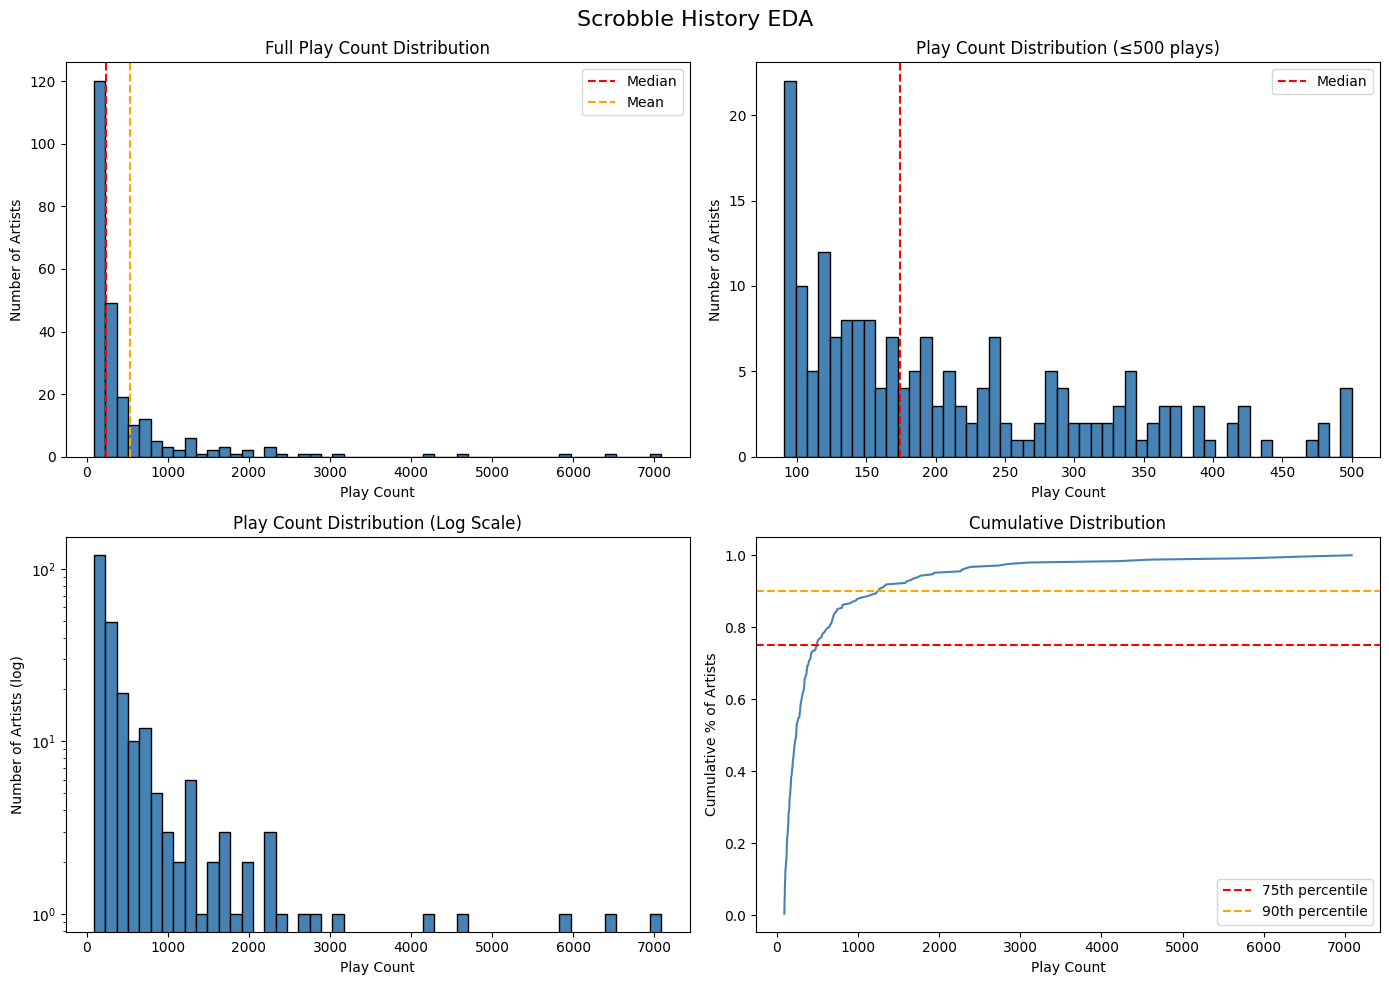

Total artists that exceed 1000: 30


In [37]:
play_counts = artists_df['play_count'].tolist()

# Basic stats
print("=== Descriptive Statistics ===")
print(f"Total artists: {len(play_counts)}")
print(f"Max plays: {max(play_counts)}")
print(f"Min plays: {min(play_counts)}")
print(f"Median plays: {int(np.median(play_counts))}")
print(f"Mean plays: {np.mean(play_counts):.2f}")
print(f"Std dev: {np.std(play_counts):.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Scrobble History EDA', fontsize=16)

# 1. Full distribution
axes[0,0].hist(play_counts, bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Full Play Count Distribution')
axes[0,0].set_xlabel('Play Count')
axes[0,0].set_ylabel('Number of Artists')
axes[0,0].axvline(np.median(play_counts), color='red', linestyle='--', label='Median')
axes[0,0].axvline(np.mean(play_counts), color='orange', linestyle='--', label='Mean')
axes[0,0].legend()

# 2. Zoomed in
zoomed = [p for p in play_counts if p <= 500]
axes[0,1].hist(zoomed, bins=50, color='steelblue', edgecolor='black')
axes[0,1].set_title('Play Count Distribution (≤500 plays)')
axes[0,1].set_xlabel('Play Count')
axes[0,1].set_ylabel('Number of Artists')
axes[0,1].axvline(np.median(zoomed), color='red', linestyle='--', label='Median')
axes[0,1].legend()

# 3. Log scale distribution
axes[1,0].hist(play_counts, bins=50, color='steelblue', edgecolor='black', log=True)
axes[1,0].set_title('Play Count Distribution (Log Scale)')
axes[1,0].set_xlabel('Play Count')
axes[1,0].set_ylabel('Number of Artists (log)')

# 4. Cumulative distribution
sorted_counts = np.sort(play_counts)
cumulative = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1,1].plot(sorted_counts, cumulative, color='steelblue')
axes[1,1].set_title('Cumulative Distribution')
axes[1,1].set_xlabel('Play Count')
axes[1,1].set_ylabel('Cumulative % of Artists')
axes[1,1].axhline(0.75, color='red', linestyle='--', label='75th percentile')
axes[1,1].axhline(0.90, color='orange', linestyle='--', label='90th percentile')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f'Total artists that exceed 1000: {(artists_df['play_count'] > 1000).sum()}')  # how many exceed 1000

#### **Insights:**
- The play count distribution shows that scrobbles (aka plays / listens) are heavily right-skewed, meaning a large majority of artists recorded in my LastFM listening history have less than ~1000 total listens.
    - The mean and median of play counts further show that a large portion of the artists is densely focused between the <1000 listens area which further confirm my hypothesis.
    - For a listening distribtion, this is normal since only a few artists would tend to be listened to repeatedly (hardcore faves), while a majority of other artists would have listens on the smaller end (casual - occasional listens).
- Zoomed in play count distribution shows that most artists only have ~100 total artists, slowly tapering off until the 500 total listens mark.
    -   Artists with $\small \leq$100 listens can be classified as 'accidental' listens
- Based on the log scaled distribution, artists that have more than 1000 total listens are sparse in the dataset.
    - The cumulative distribution indicates that 75% of artists have less than 1000 listens (~185 artists) while 90% of artists have less than ~1500 listens (~222 artists).

## **Tag / Genre Distribution**

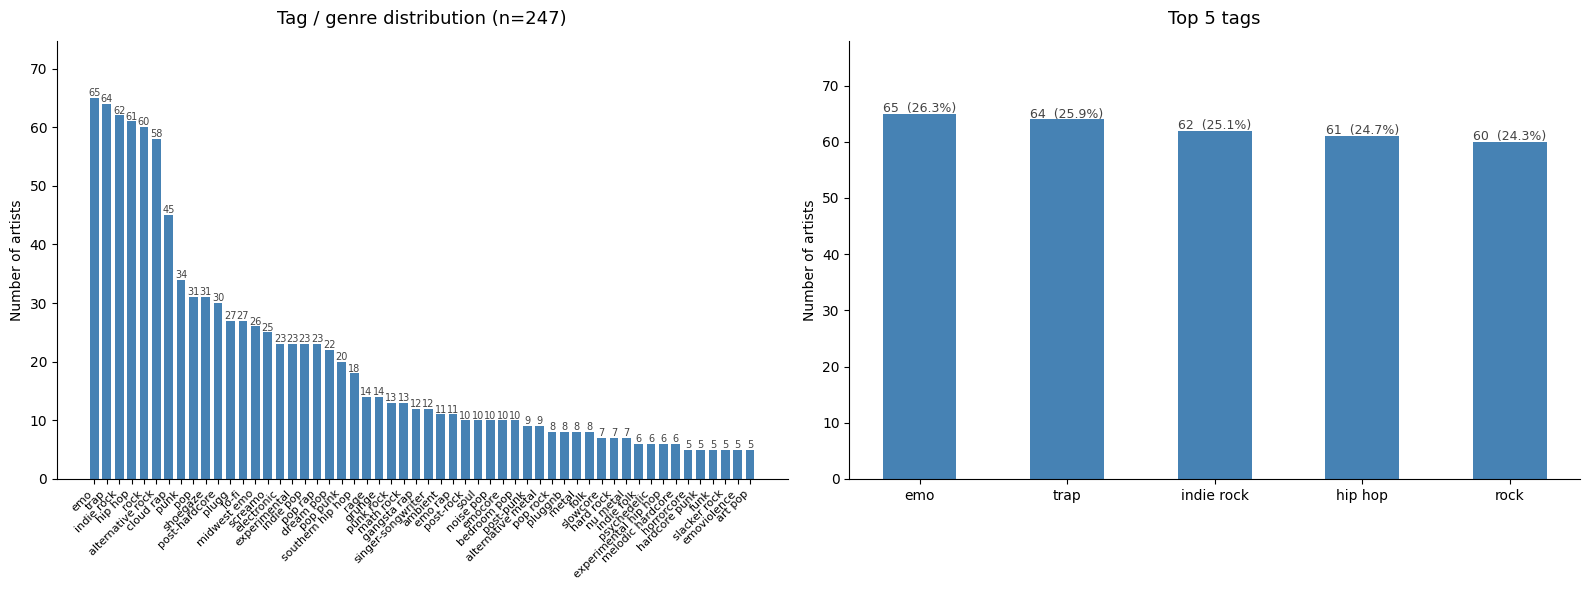

Top 5 exclusively indie rock artists by play count:
    artist_name  play_count
   wifiskeleton        1582
         Alex G        1259
Modern Baseball        1044
       Panchiko         810
       Marietta         739
Top 5 exclusively rock artists by play count:
                artist_name  play_count
                   Deftones        2737
                     Jaydes        2385
                    Nirvana        1650
        My Chemical Romance        1169
i wanna be a jack-o-lantern         561


In [40]:
tag_cols = final_df.columns.difference(['artist_name', 'play_count', 'url']).tolist()
tag_counts = final_df[tag_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# full distribution
bars = axes[0].bar(tag_counts.index, tag_counts.values, color='steelblue', edgecolor='none', width=0.7)
for bar, val in zip(bars, tag_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                 str(val), ha='center', fontsize=7, color='#444')
axes[0].set_ylabel('Number of artists')
axes[0].set_title(f'Tag / genre distribution (n={len(final_df)})', fontsize=13, pad=12)
axes[0].set_xticks(range(len(tag_counts)))
axes[0].set_xticklabels(tag_counts.index, rotation=45, ha='right', fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_ylim(0, tag_counts.max() * 1.15)

# top 5
top5 = tag_counts.head(5)
bars2 = axes[1].bar(top5.index, top5.values, color='steelblue', edgecolor='none', width=0.5)
for bar, val in zip(bars2, top5.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                 f'{val}  ({val / len(final_df) * 100:.1f}%)',
                 ha='center', fontsize=9, color='#444')
axes[1].set_ylabel('Number of artists')
axes[1].set_title('Top 5 tags', fontsize=13, pad=12)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_ylim(0, top5.max() * 1.2)

plt.tight_layout()
plt.show()

# indie rock vs. rock genre
print('=' * 50)
print("Top 5 exclusively indie rock artists by play count:")
print(final_df[(final_df['indie rock'] == 1) & (final_df['rock'] == 0)].nlargest(5, 'play_count')[['artist_name', 'play_count']].to_string(index=False))

print('=' * 50)
print("Top 5 exclusively rock artists by play count:")
print(final_df[(final_df['rock'] == 1) & (final_df['indie rock'] == 0)].nlargest(5, 'play_count')[['artist_name', 'play_count']].to_string(index=False))

#### **Insights:**

- The genre distribution is heavily right skewed, with a set of 'broader' genres such as `trap`, `emo`, `hip hop`, `indie rock` and `rock` dominating.
- Genres such as `trap`, `emo`, and `indie rock` in LastFM aren't necessarily categorized as a more 'specific' genre / subgenre per se, nor are they necessarily part of any real hierarchy of genres or subgenres (i.e rock -> indie rock or hip hop -> trap).
    - In the case of `emo`, the genre has both been used to refer to both the original indie/punk subculture (Cap'n Jazz, Sunny Day Real Estate) and to the contemporary label applied to emotionally raw artists across hip hop, pop punk, and other genres (Lil Uzi Vert, Paramore, Panic! At The Disco).
    - Similarly, users most likely felt the `indie rock` tag to be a more apt description of artists that are closer both to independently produced music (Alex G, Panchiko) as well as the indie aesthetic (wifiskeleton) over the `rock` tag which usually implies mainstream acts such as Deftones, My Chemical Romance and Nirvana.
        - Worth noting is that the tags system is based on user-driven inputs, and then subsequently aggregated and weighted by how many users applied them.
        - As a result, tagging becomes inconsistent with heavy recency bias, prioritizing overall cultural consensus over accuracy (i.e Nirvana not being `indie rock` despite independent roots), and obscure artists resulting in a less reliable classified genre (i.e Jaydes and i wanna be a jack-o-lantern as `rock`).

## **Tag Count Per Artist**

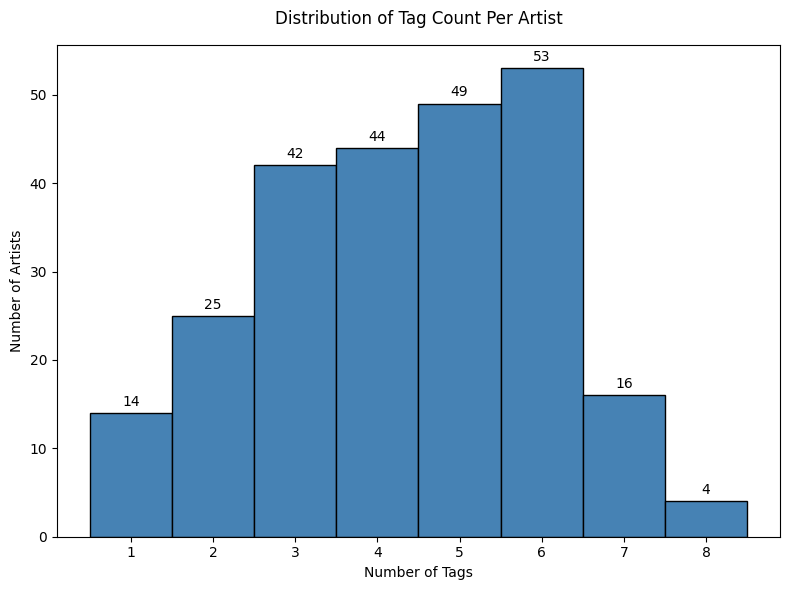

Mean Tag Count per Artist: 4.34
List of Artists with One Tag:
   artist_name        tags
Kendrick Lamar   [hip hop]
    Steve Lacy      [soul]
          Lamp [indie pop]
       MF DOOM   [hip hop]
       Fulcrum     [plugg]
      DECALIUS     [metal]
       Takeoff      [trap]
       J. Cole   [hip hop]
         Nunya      [punk]
      NewJeans       [pop]
   LE SSERAFIM       [pop]
   Joey Bada$$   [hip hop]
          imsg     [plugg]
         evvls       [emo]


In [43]:
tag_counts = artists_df['tags'].str.len()

fig, ax = plt.subplots(figsize=(8, 6))

# Define explicit integer bin edges from 1 to max+1
# This ensures each bar represents exactly ONE integer
bins = np.arange(1, max(tag_counts) + 2)

counts, edges, bars = ax.hist(tag_counts, bins=bins, color='steelblue', edgecolor='black', align='left')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Distribution of Tag Count Per Artist', pad=15)
ax.set_xlabel('Number of Tags')
ax.set_ylabel('Number of Artists')

# Explicitly set x-ticks to show every integer perfectly
ax.set_xticks(range(1, max(tag_counts) + 1))

plt.tight_layout()
plt.show()

print(f'Mean Tag Count per Artist: {tag_counts.mean().round(2)}')
# Check artists with one tag
artists_df['tag_count'] = artists_df['tags'].apply(len)

print('=' * 50, '\nList of Artists with One Tag:')
print(artists_df[artists_df['tag_count'] <= 1][['artist_name', 'tags']].to_string(index=False))

#### **Insights:**
- Based on the distribution, on average, each artist at least has 4.33 valid tags / genres applied to their LastFM artist page.
- 15 artists out of 247 (6%) have only one tag even after increasing tag limit to 15.
    - This is mainly due to removing sparse tags in the dataset which led these artists to only have one genre of which they represent the most.
    - Removing these artists may result in further data loss, so they stay as edge cases in our data.

## **Genre Correlation Heatmap**

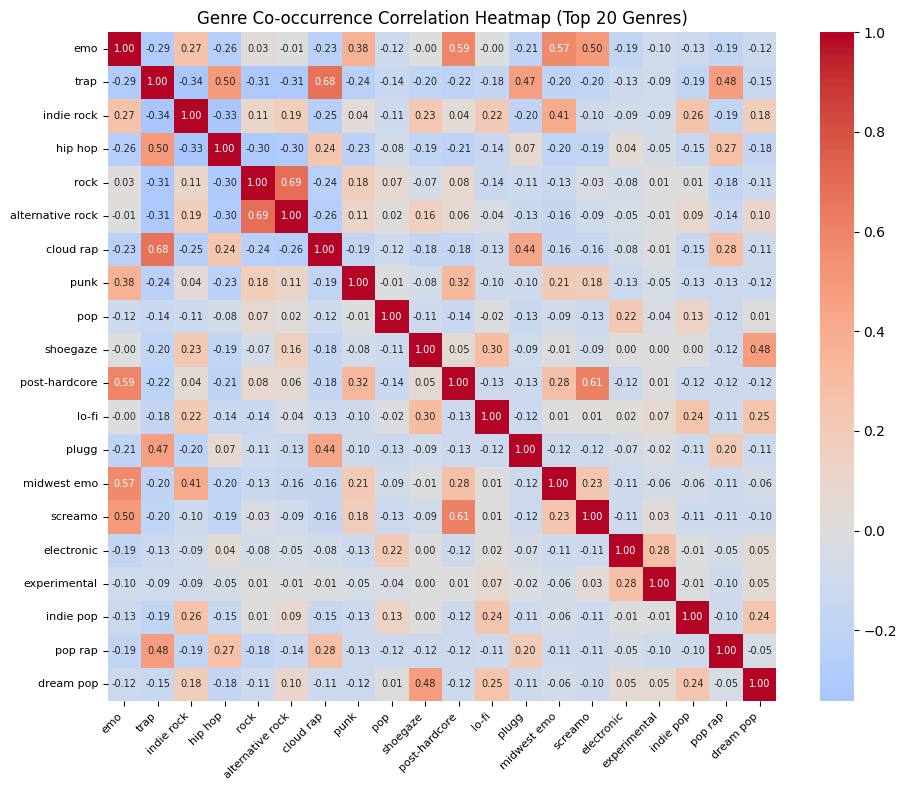

Strongest Correlations (co-occur frequently)
         genre_1       genre_2  correlation
alternative rock          rock     0.688443
       cloud rap          trap     0.678423
   post-hardcore       screamo     0.614887
             emo post-hardcore     0.594025
             emo   midwest emo     0.573944
             emo       screamo     0.500563
         hip hop          trap     0.496983
       dream pop      shoegaze     0.482180
         pop rap          trap     0.478250
           plugg          trap     0.473934
Weakest Correlations (rarely appear together)
         genre_1    genre_2  correlation
      indie rock       trap    -0.342353
         hip hop indie rock    -0.331527
            rock       trap    -0.313433
alternative rock       trap    -0.305804
         hip hop       rock    -0.302495
alternative rock    hip hop    -0.295095
             emo       trap    -0.290463
alternative rock  cloud rap    -0.261465
             emo    hip hop    -0.256960
       cloud ra

In [46]:
# get only the OHE columns
ohe_cols = mlb.classes_
ohe_df = final_df[ohe_cols]

# correlation matrix
top_genres = ohe_df.sum().nlargest(20).index
corr_matrix = ohe_df[top_genres].corr()

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    annot_kws={'size': 7},
    square=True
)
plt.title('Genre Co-occurrence Correlation Heatmap (Top 20 Genres)', fontsize=12)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# find strongly correlated genre pairs
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1]  # remove self-correlation

# remove duplicates (A-B and B-A are the same pair)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]

# reset index and rename columns
corr_pairs = corr_pairs.reset_index()
corr_pairs.columns = ['genre_1', 'genre_2', 'correlation']

strong_positive = corr_pairs[corr_pairs['correlation'] > 0.3].sort_values('correlation', ascending=False)
strong_negative = corr_pairs[corr_pairs['correlation'] < -0.1].sort_values('correlation')

print("=" * 50, "\nStrongest Correlations (co-occur frequently)")
print(strong_positive.head(10).to_string(index=False))

print("=" * 50, "\nWeakest Correlations (rarely appear together)")
print(strong_negative.head(10).to_string(index=False))

#### **Insights:**
- Based on the correlation heatmap matrix, the strongest correlations are the genres that both make sense sonically and are commonly paired together (`cloud rap` - `trap`, `emo` - `midwest emo`, `dream pop` - `shoegaze`).
- On the other hand, the weakest correlations are the genres that rarely appear together, whether it may be through it being a niche pairing or generally not making sense sonically (`indie rock` - `trap`, `rock` - `trap`, `cloud rap` - `indie rock`).

# **Data Modeling**

## **K-Means Clustering**

### **Feature Selection and Scaling**

#### **TF-IDF**

**Problem**: Artists are frequently tagged with broad genres such as `hip hop`, `rock`, `emo`, where it leads to these generalized broad genres simply just dominating everything telling us literally nothing about our actual music taste. Every artist becomes similar to each other simply because they have some combination of the same genres.

**Solution**: Utilize Term Frequency-Inverse Document Frequency (TF-IDF), penalizing tags that are broad and frequently appear everywhere by downweighting them and rewarding tags that are rarer and more specific. This makes it so that when K-means clusters, it's not necessarily just the big genres `hip hop` vs. `rock` vs. `emo`, it becomes more niche-driven and specific.

In [51]:
# Joins tags list into a single string per artist
tags_joined = artists_df['tags'].apply(
    lambda x: ' '.join([tag.replace('-', '_').replace(' ', '_') for tag in x]) 
    if isinstance(x, list) else ''
)

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(tags_joined)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray().round(3),
    columns=tfidf.get_feature_names_out(),
    index=[f'Doc{i+1}' for i in range(len(tags_joined))]
)

print(f"TF-IDF matrix shape: {tfidf_df.shape}")
print(f"Unique tags: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape: (247, 54)
Unique tags: 54


### **Find Optimal K**

#### **Elbow Analysis & Newton-Raphson**

In [54]:
K_range = range(1, 11)
wcss = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=300)
    km.fit(tfidf_matrix)
    wcss.append(km.inertia_)

# Discrete first and second differences
ks  = np.array(list(K_range), dtype=float)
ws  = np.array(wcss, dtype=float)
d1  = np.diff(ws)        # ΔInertia  ≈ f'(K)
d2  = np.diff(d1)        # ΔΔInertia ≈ f''(K)
ks2 = ks[1:-1]           # K values aligned with d2

# Print elbow table
print("--- Elbow Analysis ---")
print(f"{'K':<6}{'WCSS':<12}{'ΔInertia':>12}{'ΔΔInertia':>12}")
print("-" * 44)
for i, (k, w) in enumerate(zip(ks, ws)):
    d1_str = f"{d1[i-1]:>12.2f}" if i >= 1 else f"{'—':>12}"
    d2_str = f"{d2[i-2]:>12.2f}" if i >= 2 else f"{'—':>12}"
    print(f"  {int(k):<6}{w:<12.2f}{d1_str}{d2_str}")

# Fit quadratic to ΔΔInertia and run Newton-Raphson
coeffs = np.polyfit(ks2, d2, 2)
p      = np.poly1d(coeffs)
dp     = p.deriv()

print("\n--- Newton-Raphson Iterations (finding root of ΔΔInertia fit) ---")
print(f"{'n':<6}{'Kₙ':<12}{'p(Kₙ)':<14}{'p′(Kₙ)':<14}{'Kₙ₊₁':<12}{'|ΔK|'}")
print("-" * 62)

K = float(ks2.mean())
for i in range(50):
    pk    = p(K)
    dpk   = dp(K)
    if abs(dpk) < 1e-12:
        break
    K_new = K - pk / dpk
    delta = abs(K_new - K)
    print(f"  {i:<6}{K:<12.4f}{pk:<14.4f}{dpk:<14.4f}{K_new:<12.4f}{delta:.6f}")
    K = K_new
    if delta < 1e-6:
        break

optimal_k = int(round(np.clip(K, ks[0], ks[-1])))
print(f"\nNewton-Raphson converged at K* = {K:.4f}  →  Optimal K = {optimal_k}")

--- Elbow Analysis ---
K     WCSS            ΔInertia   ΔΔInertia
--------------------------------------------
  1     219.65                 —           —
  2     195.10            -24.54           —
  3     181.89            -13.22       11.33
  4     172.42             -9.47        3.75
  5     163.89             -8.53        0.93
  6     157.13             -6.76        1.78
  7     150.61             -6.52        0.23
  8     145.77             -4.83        1.69
  9     139.33             -6.45       -1.61
  10    134.35             -4.98        1.47

--- Newton-Raphson Iterations (finding root of ΔΔInertia fit) ---
n     Kₙ          p(Kₙ)         p′(Kₙ)        Kₙ₊₁        |ΔK|
--------------------------------------------------------------
  0     5.5000      0.1402        -1.1323       5.6238      0.123849
  1     5.6238      0.0067        -1.0236       5.6304      0.006580
  2     5.6304      0.0000        -1.0178       5.6304      0.000019
  3     5.6304      0.0000        -1.01

#### **Insights:**
- Utilize Newton-Raphson method as it is able to best determine the "elbow" of the WCSS.
- Still need to check silhouette analysis and elbow plots to better determine whether ``K=6`` is truly the optimal K.

Mathematical Elbow detected at K = 6


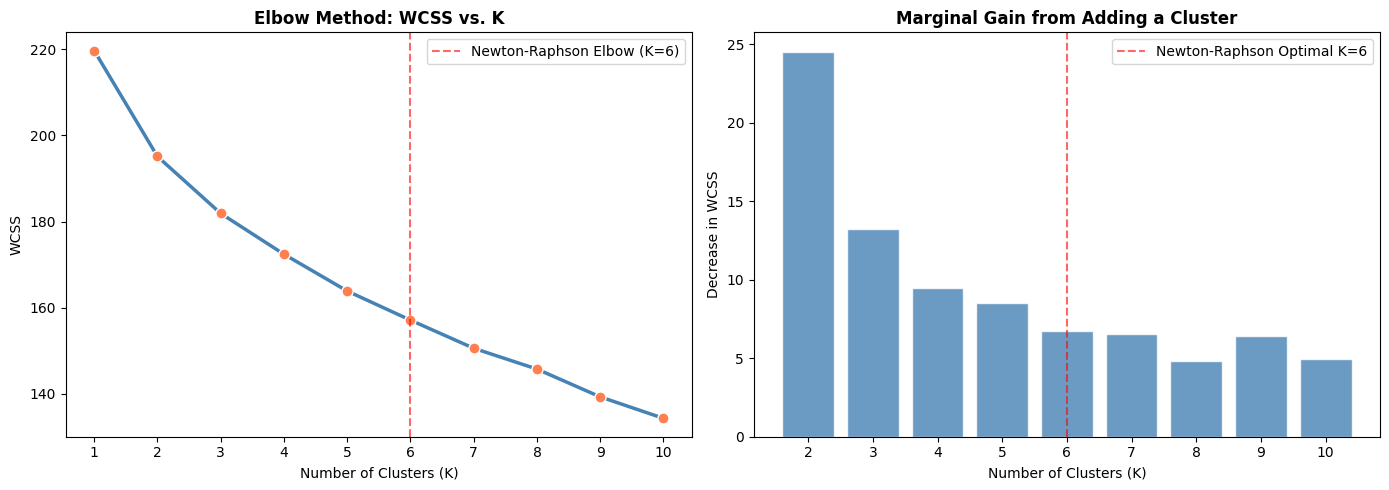

In [56]:
print(f"Mathematical Elbow detected at K = {optimal_k}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Plot: Elbow Curve ---
ax1.plot(list(K_range), wcss, marker='o', color='steelblue', linewidth=2.5,
         markersize=8, markerfacecolor='coral', markeredgecolor='white')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method: WCSS vs. K', fontweight='bold')
ax1.set_xticks(list(K_range))
ax1.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.6,
            label=f'Newton-Raphson Elbow (K={optimal_k})')
ax1.legend()

# --- Right Plot: Marginal Decrease ---
delta_wcss = [wcss[i-1] - wcss[i] for i in range(1, len(wcss))]
k_labels = list(range(2, len(list(K_range)) + 1))
ax2.bar(k_labels, delta_wcss, color='steelblue', alpha=0.8, edgecolor='white')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Decrease in WCSS')
ax2.set_title('Marginal Gain from Adding a Cluster', fontweight='bold')
ax2.set_xticks(k_labels)
ax2.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.6,
            label=f'Newton-Raphson Optimal K={optimal_k}')
ax2.legend()

plt.tight_layout()
plt.show()

#### **Silhouette Scores in finding K**

Silhouette Analysis:
----------------------------------------
    K  |   Mean Silhouette Score
----------------------------------------
  K=2  |                  0.1103
  K=3  |                  0.1175
  K=4  |                  0.1201
  K=5  |                  0.1279
  K=6  |                  0.1188
  K=7  |                  0.1240
----------------------------------------


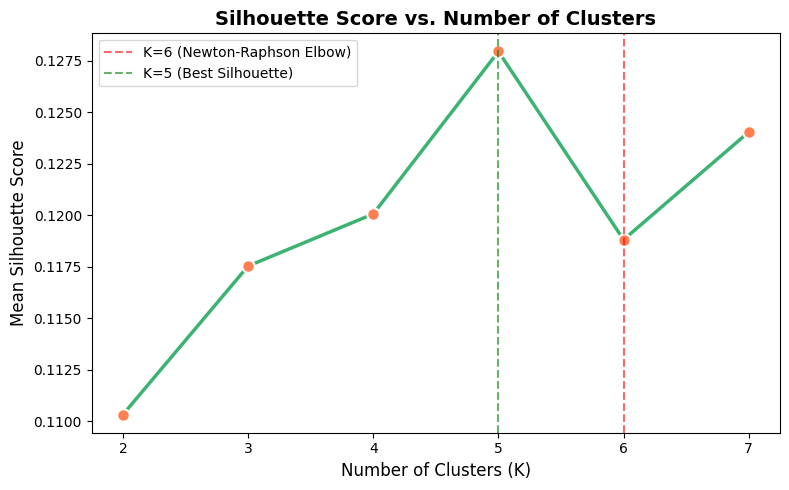


Best K by silhouette score: K=5 (score = 0.1279)


In [58]:
K_test = range(2, 8)
silhouette_scores = []

print("Silhouette Analysis:")
print("-" * 40)
print(f"{'K':>5}  |  {'Mean Silhouette Score':>22}")
print("-" * 40)

for k in K_test:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=300)
    labels = km.fit_predict(tfidf_matrix)
    score = silhouette_score(tfidf_matrix, labels)
    silhouette_scores.append(score)
    print(f"  K={k}  |  {score:>22.4f}")

print("-" * 40)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(K_test), silhouette_scores, marker='o', color='mediumseagreen', linewidth=2.5,
         markersize=9, markerfacecolor='coral', markeredgecolor='white', markeredgewidth=1.5)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Mean Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs. Number of Clusters', fontsize=14, fontweight='bold')
plt.xticks(list(K_test))
plt.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.6, 
            label=f'K={optimal_k} (Newton-Raphson Elbow)')
best_k = list(K_test)[silhouette_scores.index(max(silhouette_scores))]
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.6, 
            label=f'K={best_k} (Best Silhouette)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest K by silhouette score: K={best_k} (score = {max(silhouette_scores):.4f})")

optimal_k = 5

#### **Insights:**

- Moving forward, I will be utilizing K=5. This is due to silhouette score rapidly dropping at K=6, while it is at its highest at K=5
- The $\small{\triangle \triangle}$Inertia is at its lowest at K=5 compared to K=6 where it actually rose.
- Looking closer at Newton-Raphson method, K converged at 5.63 but rounded up to 6, which means it's closer to K=5 than it appears.
- It should be noted that the low silhouette score is a byproduct of listening data. Genres in and of itself are generally arbitrary, what a user may determine an artist's genre to be could be totally different from someone else.

### **Silhouette Plot Comparison**

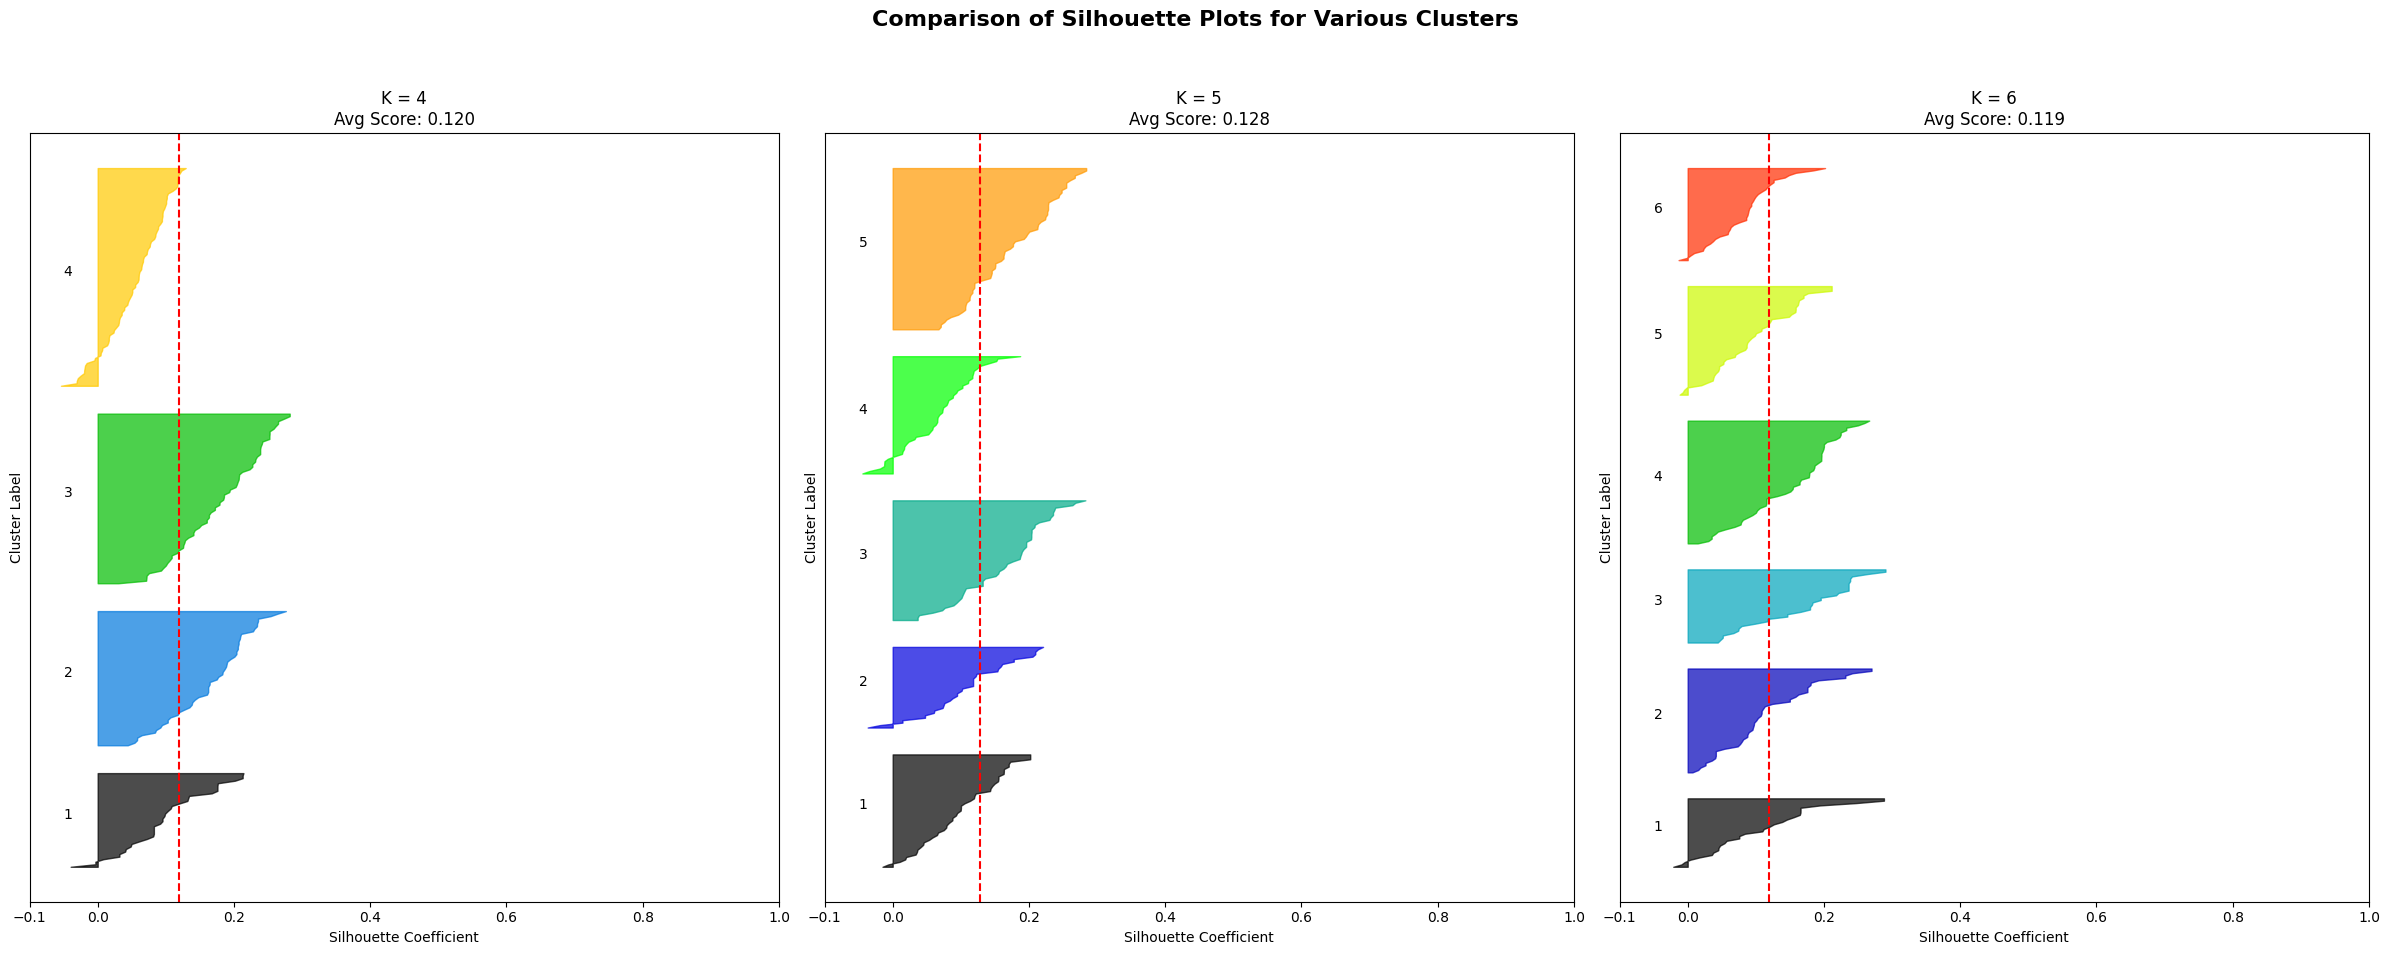

In [61]:
# Compare K values around our optimal
range_n_clusters = [4, 5, 6]

km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42, max_iter=300)
labels_final = km_final.fit_predict(tfidf_matrix)

# Create a figure with subplots (1 row, multiple columns)
fig, axes = plt.subplots(1, len(range_n_clusters), figsize=(24, 10))

for idx, n_clusters in enumerate(range_n_clusters):
    ax = axes[idx]
    
    # Initialize and fit KMeans
    clusterer = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(tfidf_matrix)
    
    # Calculate scores
    silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
    sample_silhouette_values = silhouette_samples(tfidf_matrix, cluster_labels)
    
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i + 1))
        y_lower = y_upper + 10

    ax.set_title(f"K = {n_clusters}\nAvg Score: {silhouette_avg:.3f}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster Label")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.suptitle("Comparison of Silhouette Plots for Various Clusters", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### **Insights:**

- Looking at each silhouette plot, the clear-cut best K would still be ``K=5``
- While ``K=4`` has the least amount of clusters, both yellow and blue clusters dominate and are too wide leading to the green cluster falling short. This suggests that four clusters are over-generalizing the genre groups.
- ``K=5`` has the most even and balanced distribution out of all three plots. Clusters 2-4 are relatively even, where all clusters are past the red dotted average line.
- For ``K=6``, the clusters are too fragmented, suggesting that it is over-splitting of coherent genre groups. Cluster 6 and 5 are too small, suggesting the additional cluster does not reduce within-cluster variance meaningfully. It also has the lowest silhouette score out of the three.

### **Fit Final K-means Model**

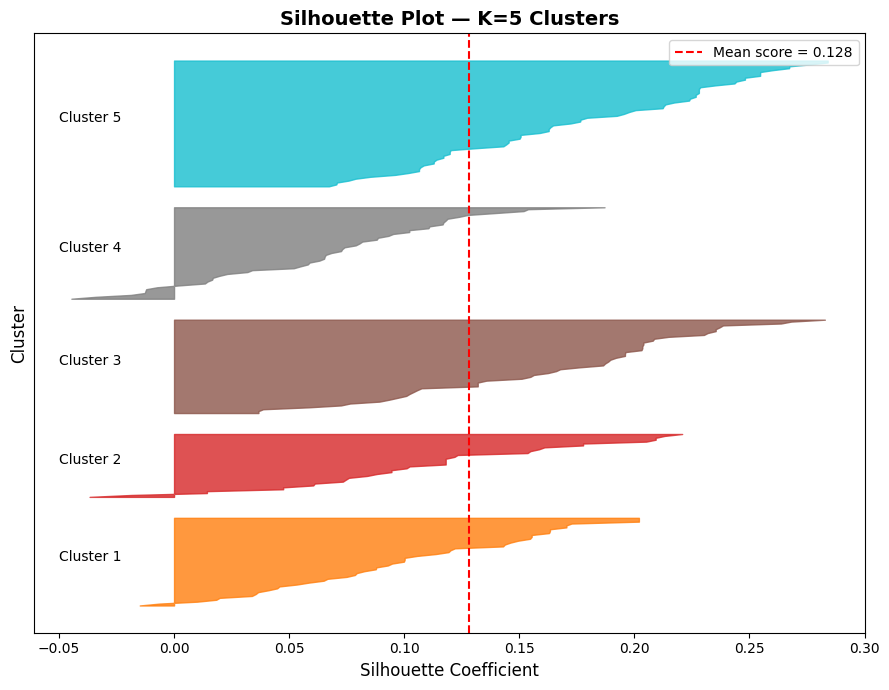

Silhouette Score: 0.1279
Davies-Bouldin Index: 2.5450
Calinski-Harabasz Index: 20.5841


In [64]:
K_final = 5
km_final = KMeans(n_clusters=K_final, init='k-means++', n_init=10, random_state=42, max_iter=300)
labels_final = km_final.fit_predict(tfidf_df)

silhouette_vals = silhouette_samples(tfidf_df, labels_final)
avg_score = silhouette_score(tfidf_df, labels_final)

s_score_k = silhouette_score(tfidf_df, labels_final)
db_index_k = davies_bouldin_score(tfidf_df, labels_final)
ch_index_k = calinski_harabasz_score(tfidf_df, labels_final)

fig, ax = plt.subplots(figsize=(9, 7))
y_lower = 10
colors = cm.tab10(np.linspace(0.1, 0.9, K_final))

for i in range(K_final):
    cluster_sil_vals = silhouette_vals[labels_final == i]
    cluster_sil_vals.sort()
    cluster_size = len(cluster_sil_vals)
    y_upper = y_lower + cluster_size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_sil_vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * cluster_size, f'Cluster {i+1}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean score = {avg_score:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot — K={K_final} Clusters', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Silhouette Score: {s_score_k:.4f}")
print(f"Davies-Bouldin Index: {db_index_k:.4f}")
print(f"Calinski-Harabasz Index: {ch_index_k:.4f}")

### **Dimensionality Reduction**
- **Problem:** Since our TF-IDF dataframe contains 57 columns / dimensions, I'll need to be able to project the high-dimensionality of each genre to a 2-dimensional space in order to fully prepare, capture and visualize the clusters without removing any features.
- **Solution:** Utilize PCA & UMAP as dimensionality reduction methods in order to properly visualize the clustering of K-Means

#### **PCA**

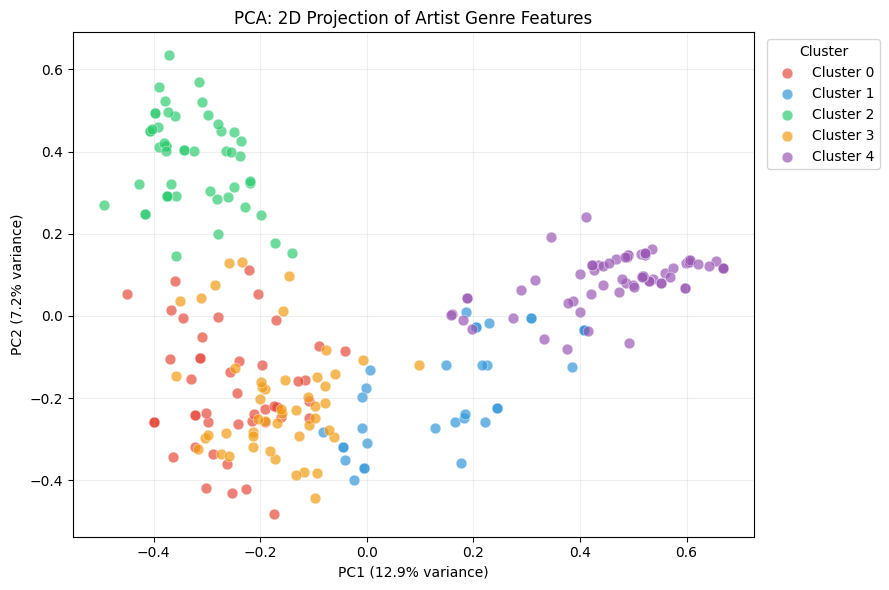

PCA 2D PROJECTION SUMMARY
  PC1 explains: 12.94% of variance
  PC2 explains: 7.16% of variance
  Combined:     20.11%

Top 5 genres contributing most to PC1 (by absolute loading):
  +0.445  trap
  +0.425  hip_hop
  +0.330  cloud_rap
  -0.249  indie_rock
  -0.237  emo

Top 5 genres contributing most to PC2 (by absolute loading):
  +0.433  emo
  +0.324  midwest_emo
  -0.284  pop
  +0.283  screamo
  +0.282  post_hardcore



In [68]:
# Project onto first two PCs (visualization)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(tfidf_df)

# Project onto first ten PCs (downstream use e.g. UMAP, KMeans input)
pca_10 = PCA(n_components=10, random_state=42)
X_pca_10 = pca_10.fit_transform(tfidf_df)

# Extract cluster labels from fitted KMeans model
cluster_labels = km_final.labels_

assert len(cluster_labels) == len(tfidf_df), (
    f"Mismatch: cluster_labels has {len(cluster_labels)} labels, tfidf_df has {len(tfidf_df)} rows"
)

n_clusters = len(np.unique(cluster_labels))
colors = {
    0: '#e74c3c',  # red
    1: '#3498db',  # blue
    2: '#2ecc71',  # green
    3: '#f39c12',  # orange
    4: '#9b59b6',  # purple
}
# 2D scatter plot
fig, ax = plt.subplots(figsize=(9, 6))

for cls in range(n_clusters):
    mask = (cluster_labels == cls)  # fixed — was km_final == cls
    ax.scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        color=colors[cls], label=f'Cluster {cls}',
        alpha=0.7, s=60, edgecolors='white', linewidths=0.4
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA: 2D Projection of Artist Genre Features')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Summary
print("=" * 70)
print("PCA 2D PROJECTION SUMMARY")
print("=" * 70)
print(f"  PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"  PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.2f}% of variance")
print(f"  Combined:     {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")
print()

# Top contributing genres per PC
genre_cols = tfidf_df.columns.tolist()
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=genre_cols,
    columns=['PC1', 'PC2']
)

for pc in ['PC1', 'PC2']:
    print(f"Top 5 genres contributing most to {pc} (by absolute loading):")
    top = loadings[pc].abs().sort_values(ascending=False).head(5)
    for genre, val in top.items():
        direction = "+" if loadings.loc[genre, pc] > 0 else "-"
        print(f"  {direction}{abs(val):.3f}  {genre}")
    print()

#### **UMAP**

UMAP: EXPLORING n_neighbors SENSITIVITY

UMAP key parameters:
  n_neighbors: local vs global tradeoff (5 = local, 50 = global)
  min_dist:    how tightly to pack points in 2D
  random_state: always set

  Fitting UMAP with n_neighbors=5... done
  Fitting UMAP with n_neighbors=15... done
  Fitting UMAP with n_neighbors=50... done


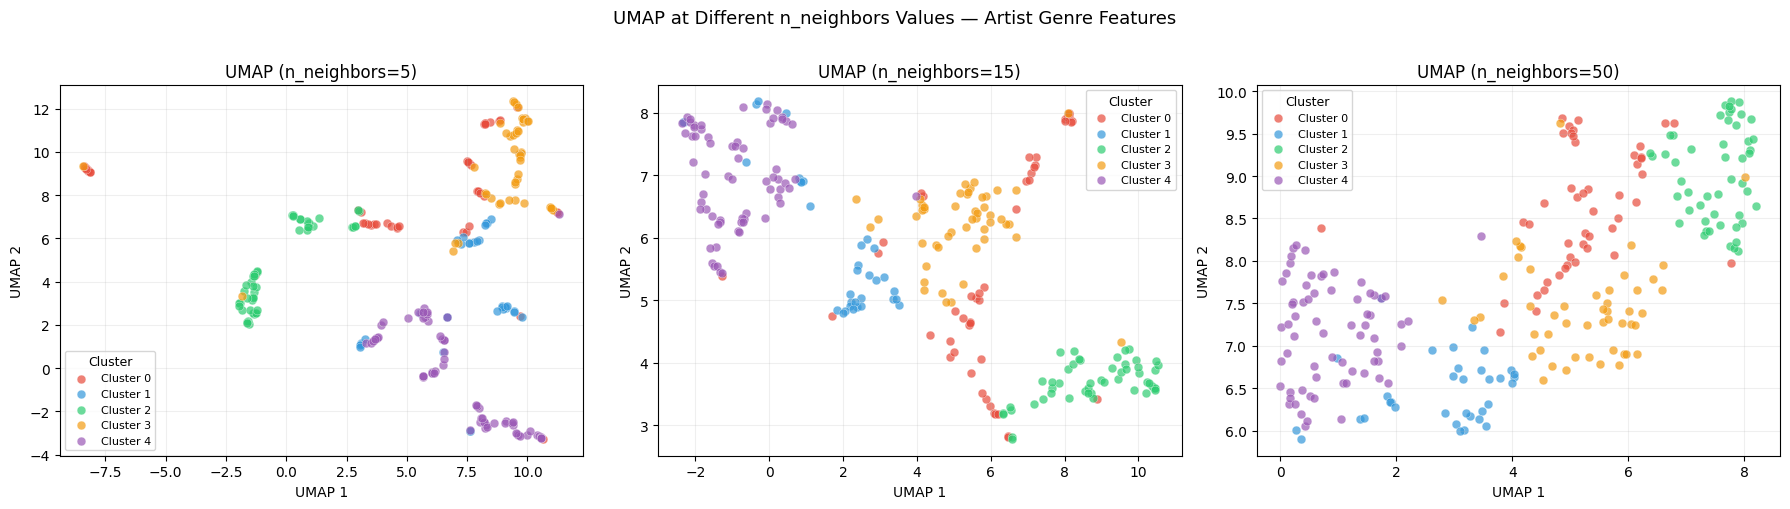


Observations:
  • Small n_neighbors (5):  fragmented, emphasis on local genre structure.
  • n_neighbors=15:         good balance, preserves local and global.
  • Large n_neighbors (50): smoother, global genre structure emphasized.

UMAP vs PCA on this dataset:
  • PCA (20.4% variance): linear projection, loses non-linear structure.
  • UMAP: captures non-linear genre relationships PCA cannot show.
  • UMAP can embed new artists at inference time; t-SNE cannot.


In [70]:
if UMAP_AVAILABLE:
    print("=" * 70)
    print("UMAP: EXPLORING n_neighbors SENSITIVITY")
    print("=" * 70)
    print()
    print("UMAP key parameters:")
    print("  n_neighbors: local vs global tradeoff (5 = local, 50 = global)")
    print("  min_dist:    how tightly to pack points in 2D")
    print("  random_state: always set")
    print()

    neighbor_values = [5, 15, 50]
    umap_results = {}

    for n in neighbor_values:
        print(f"  Fitting UMAP with n_neighbors={n}...", end=" ")
        reducer = umap.UMAP(n_components=2, n_neighbors=n,
                            min_dist=0.1, random_state=42)
        umap_results[n] = reducer.fit_transform(tfidf_df)
        print("done")

    # Plot all three n_neighbors values
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, n in zip(axes, neighbor_values):
        Z = umap_results[n]
        for cls in range(n_clusters):
            mask = (cluster_labels == cls)
            ax.scatter(
                Z[mask, 0], Z[mask, 1],
                color=colors[cls], label=f'Cluster {cls}',
                alpha=0.7, s=40, edgecolors='white', linewidths=0.3
            )
        ax.set_title(f'UMAP (n_neighbors={n})')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.legend(title='Cluster', fontsize=8, title_fontsize=9)
        ax.grid(True, alpha=0.2)

    plt.suptitle('UMAP at Different n_neighbors Values — Artist Genre Features',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print()
    print("Observations:")
    print("  • Small n_neighbors (5):  fragmented, emphasis on local genre structure.")
    print("  • n_neighbors=15:         good balance, preserves local and global.")
    print("  • Large n_neighbors (50): smoother, global genre structure emphasized.")
    print()
    print("UMAP vs PCA on this dataset:")
    print("  • PCA (20.4% variance): linear projection, loses non-linear structure.")
    print("  • UMAP: captures non-linear genre relationships PCA cannot show.")
    print("  • UMAP can embed new artists at inference time; t-SNE cannot.")

else:
    print("UMAP not available. Install with: pip install umap-learn")
    print("Skipping UMAP section.")

#### **Insights:**
- Utilize ``n_neighbors=15`` as it has the best balance between local and global structure. Clusters are well separated and properly represented.


Fitting UMAP...
Done.


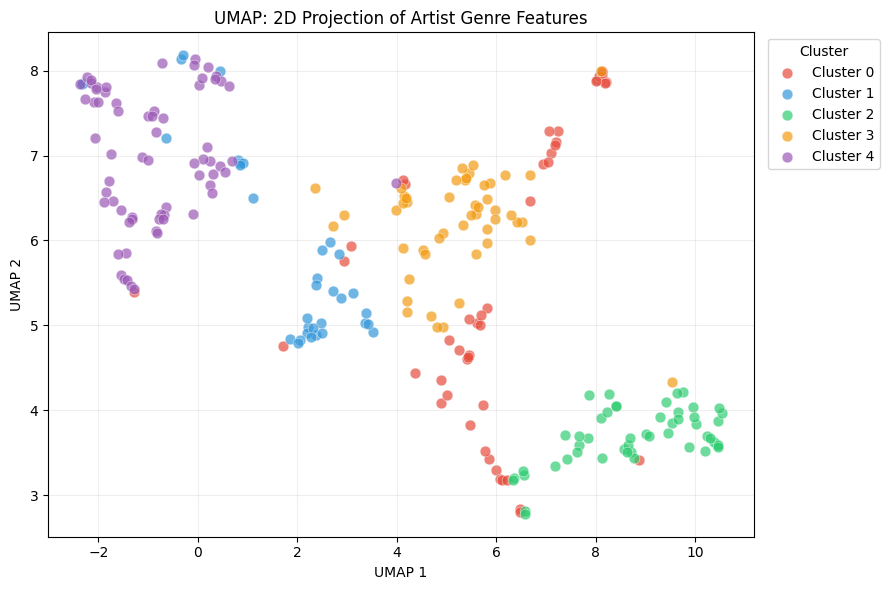

UMAP 2D PROJECTION SUMMARY
  n_neighbors : 15
  min_dist    : 0.1
  n_components: 2
  random_state: 42
  Output shape: (247, 2)


In [72]:
print("\nFitting UMAP...")
reducer_final = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_final = reducer_final.fit_transform(tfidf_df)
print("Done.")

assert len(cluster_labels) == len(tfidf_df), (
    f"Mismatch: cluster_labels has {len(cluster_labels)} labels, tfidf_df has {len(tfidf_df)} rows"
)

n_clusters = len(np.unique(cluster_labels))
colors = {
    0: '#e74c3c',  # red
    1: '#3498db',  # blue
    2: '#2ecc71',  # green
    3: '#f39c12',  # orange
    4: '#9b59b6',  # purple
}
# 2D scatter plot
fig, ax = plt.subplots(figsize=(9, 6))

for cls in range(n_clusters):
    mask = (cluster_labels == cls)  # fixed — was km_final == cls
    ax.scatter(
        X_umap_final[mask, 0], X_umap_final[mask, 1],
        color=colors[cls], label=f'Cluster {cls}',
        alpha=0.7, s=60, edgecolors='white', linewidths=0.4
    )

ax.set_xlabel(f'UMAP 1')
ax.set_ylabel(f'UMAP 2')
ax.set_title('UMAP: 2D Projection of Artist Genre Features')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Summary
print("=" * 70)
print("UMAP 2D PROJECTION SUMMARY")
print("=" * 70)
print(f"  n_neighbors : {reducer_final.n_neighbors}")
print(f"  min_dist    : {reducer_final.min_dist}")
print(f"  n_components: {reducer_final.n_components}")
print(f"  random_state: {reducer_final.random_state}")
print(f"  Output shape: {X_umap_final.shape}")

#### **Genre Cluster Labels**

In [74]:
# Align indices before attaching cluster labels
artists_df = artists_df.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)

# Attach cluster labels to your artist dataframe
artists_df['cluster'] = cluster_labels

# For each cluster: show artists and their top genres
for cls in range(n_clusters):
    subset = artists_df[artists_df['cluster'] == cls]
    print(f"{'=' * 70}")
    print(f"CLUSTER {cls}  ({len(subset)} artists)")
    print(f"{'=' * 70}")
    
    # Artists in this cluster
    print(subset[['artist_name', 'play_count']].sort_values('play_count', ascending=False).to_string(index=False))
    print()
    
    # Dominant genres (mean TF-IDF weight across cluster)
    genre_means = tfidf_df.loc[subset.index].mean().sort_values(ascending=False)
    print("Top genres:")
    print(genre_means.head(8).to_string())
    print()

CLUSTER 0  (47 artists)
                artist_name  play_count
                     Weezer        3097
                   Deftones        2737
                     Jaydes        2385
                  Radiohead        2265
                    Nirvana        1650
                       Ozma         974
                The Strokes         928
                 The Smiths         698
      The Smashing Pumpkins         673
                      Oasis         649
i wanna be a jack-o-lantern         561
        Panic! at the Disco         555
          Fried By Fluoride         529
           System of a Down         419
                  Green Day         360
               Fall Out Boy         350
                  blink-182         335
                   Gorillaz         331
             Arctic Monkeys         327
                    Weiland         315
                   Paramore         303
                Descendents         291
                   Slipknot         287
                

#### **Insights:**

- There are a few outliers based on the limitations of LastFM tags / genres, notably artists such as Alex G, Elliott Smith, Mac DeMarco and others being categorized as ``dream pop / shoegaze`` when they fit more into the indie rock genre.
    - Outsmarting Simon, They Are Gutting a Body of Water are artists also more akin to emo rather than either genres
- ``Trap / cloud rap`` managed to remarkably be correct all around, was able to properly describe most if not all artists in this cluster as trap
    - There is some overlap with the hip hop cluster overall 
- ``Rock / alt rock`` managed to mostly be correct in clustering, as most artists here are mainstream artists aside from a few outliers.
- Overall these observations are a lot more picky with actual genre taxonomy and boundaries.

### **Final K-Means Clustering Plot**

Generated cluster names:
  Cluster 0: Rock / Alternative Rock
  Cluster 1: Hip Hop / Electronic
  Cluster 2: Emo / Midwest Emo
  Cluster 3: Shoegaze / Dream Pop
  Cluster 4: Trap / Cloud Rap

Fitting UMAP...
Done.


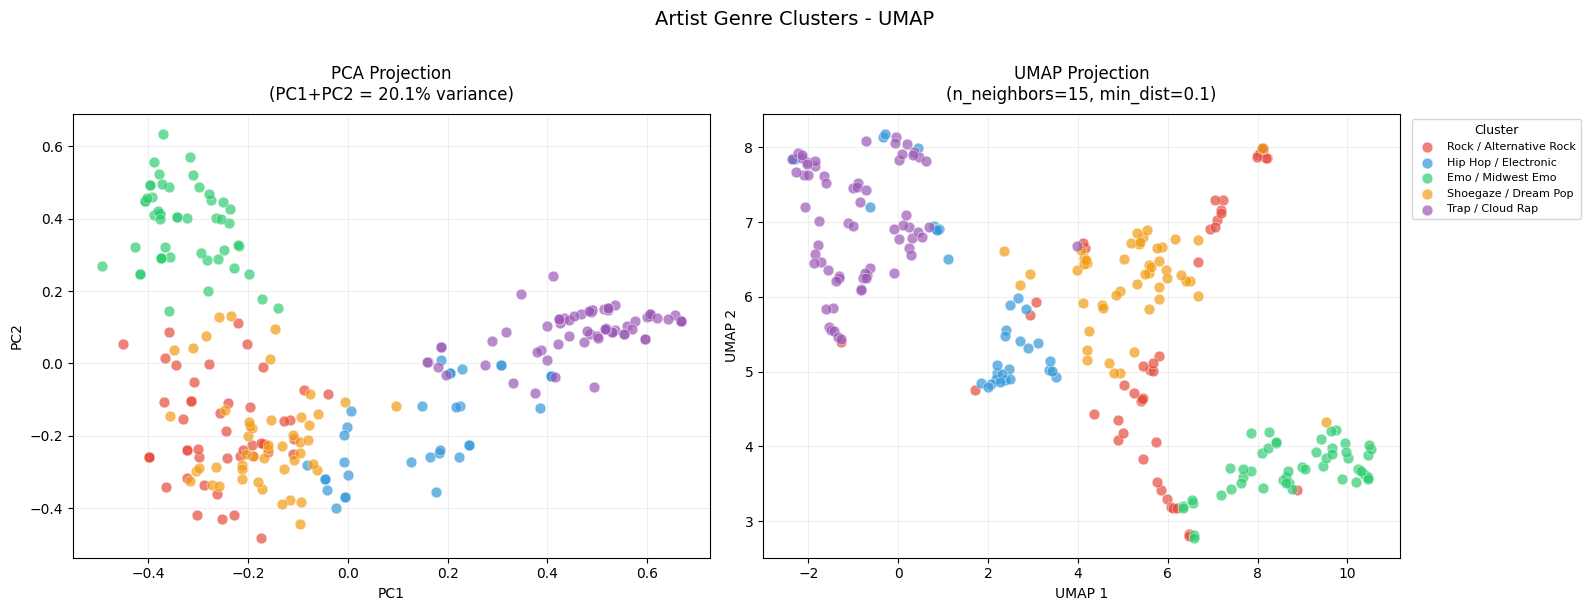

In [77]:
# Auto-name clusters from top 2 genres
cluster_names = {}
for cls in range(n_clusters):
    subset_idx = artists_df[artists_df['cluster'] == cls].index
    genre_means = tfidf_df.loc[subset_idx].mean().sort_values(ascending=False)
    top2 = genre_means.head(2).index.tolist()
    cluster_names[cls] = ' / '.join(g.replace('_', ' ').title() for g in top2)

print("Generated cluster names:")
for cls, name in cluster_names.items():
    print(f"  Cluster {cls}: {name}")

# Fit UMAP for final visualization
print("\nFitting UMAP...")
reducer_final = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_final = reducer_final.fit_transform(tfidf_df)
print("Done.")

# PCA vs UMAP side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

datasets = [
    (X_pca_2d, f'PCA Projection\n(PC1+PC2 = {sum(pca_2d.explained_variance_ratio_)*100:.1f}% variance)'),
    (X_umap_final, 'UMAP Projection\n(n_neighbors=15, min_dist=0.1)'),
]

for ax, (X_proj, title) in zip(axes, datasets):
    for cls in range(n_clusters):
        mask = (cluster_labels == cls)
        ax.scatter(
            X_proj[mask, 0], X_proj[mask, 1],
            color=colors[cls],
            label=cluster_names[cls],
            alpha=0.7, s=60,
            edgecolors='white', linewidths=0.4
        )
    ax.set_title(title, fontsize=12, pad=10)
    ax.grid(True, alpha=0.2)

axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

# Single legend on the right plot only
axes[1].legend(
    title='Cluster', fontsize=8, title_fontsize=9,
    bbox_to_anchor=(1.01, 1), loc='upper left'
)

plt.suptitle('Artist Genre Clusters - UMAP', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Insights:**
-  Proceed with UMAP projection for K-Means Clustering as it's much more reliable in its visualization over PCA.
-  UMAP is able to capture the non-linear manifold shape and pattern of the data which PCA does not.

---

## **DBScan Clustering**

### **Normalize TF-IDF**

In [82]:
tfidf_normalized = normalize(tfidf_df, norm='l2')
print(tfidf_normalized)

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.34596558]
 [0.         0.         0.         ... 0.         0.         0.35705892]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.39988405]]


**Insights:**
- Use ``cosine`` distance over ``euclidean`` for DBScan
- Normalize ``tfidf_df`` since artists with many tags has a long vector while other artists with few tags has a short vector
    - Without normalizing, each artist vector would have a different magnitude
    - Cosine distance will **only** measure the angle between two artists rather than the amount of tags they have

### **Find optimal eps value**

#### **K-Distance Plot**

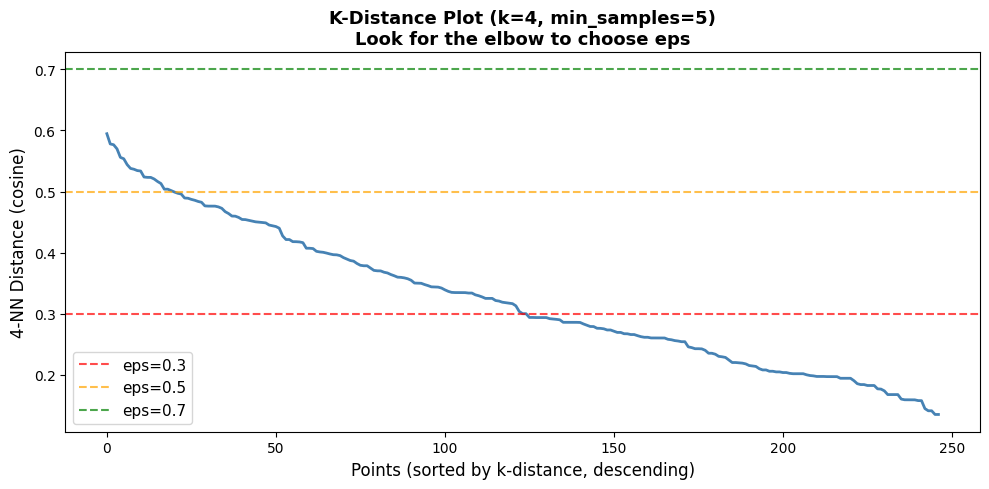

Reading the plot:
  The 'elbow' is where the curve bends sharply.
  Setting eps at the elbow separates dense (cluster) points from sparse (noise) points.


In [86]:
min_samples = 5
k = min_samples - 1  # k-distance uses k = min_samples - 1

# Fit nearest neighbors on normalized TF-IDF matrix
nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine').fit(tfidf_normalized)  # +1 because point counts itself
distances, _ = nbrs.kneighbors(tfidf_normalized)

# Get the k-th neighbor distance for each point (last column)
k_distances = np.sort(distances[:, -1])[::-1]  # sort descending

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(k_distances)), k_distances, color='steelblue', linewidth=2)
ax.set_xlabel('Points (sorted by k-distance, descending)', fontsize=12)
ax.set_ylabel(f'{k}-NN Distance (cosine)', fontsize=12)
ax.set_title(f'K-Distance Plot (k={k}, min_samples={min_samples})\nLook for the elbow to choose eps',
             fontsize=13, fontweight='bold')

# Annotate candidate eps values
for eps_candidate, color, label in [(0.3, 'red', 'eps=0.3'), (0.5, 'orange', 'eps=0.5'), (0.7, 'green', 'eps=0.7')]:
    ax.axhline(y=eps_candidate, color=color, linestyle='--', alpha=0.7, label=label)

ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Reading the plot:")
print("  The 'elbow' is where the curve bends sharply.")
print("  Setting eps at the elbow separates dense (cluster) points from sparse (noise) points.")

#### **Insights:**
- Observing the K-Distance plot, the eps values with the most 'visible' curve is 0.5, 0.3, and 0.2
    - It should be noted that the the line / curve of each eps value is very subtle, it is probably best to observe the silhouette score of each eps value

#### **Silhouette Cluster Analysis**

In [89]:
eps_values = [0.2, 0.3, 0.4, 0.5]
results = []
print(f"{'eps':>6}  |  {'Clusters':>9}  |  {'Noise pts':>10}  |  {'Noise %':>8}  |  {'Silhouette':>12}")
print("-" * 60)
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine').fit(tfidf_normalized)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    noise_pct = n_noise / len(labels) * 100

    if n_clusters >= 2:
        # Silhouette only on non-noise points
        mask = labels != -1
        sil = silhouette_score(tfidf_normalized[mask], labels[mask], metric='cosine') if mask.sum() > 1 else float('nan')
    else:
        sil = float('nan')

    results.append({'eps': eps, 'n_clusters': n_clusters, 'n_noise': n_noise,
                    'noise_pct': noise_pct, 'silhouette': sil, 'labels': labels})

    sil_str = f"{sil:.4f}" if not np.isnan(sil) else "  N/A"
    print(f"  {eps:>4}  |  {n_clusters:>9}  |  {n_noise:>10}  |  {noise_pct:>7.1f}%  |  {sil_str:>12}")

print()
print("Observations:")
print("  Compare cluster count, noise %, and silhouette across eps values")
print("  to identify the most balanced configuration.")

   eps  |   Clusters  |   Noise pts  |   Noise %  |    Silhouette
------------------------------------------------------------
   0.2  |         10  |         166  |     67.2%  |        0.4865
   0.3  |          7  |          81  |     32.8%  |        0.2929
   0.4  |          2  |          25  |     10.1%  |        0.0983
   0.5  |          1  |           1  |      0.4%  |           N/A

Observations:
  Compare cluster count, noise %, and silhouette across eps values
  to identify the most balanced configuration.


**Insights:**
- Between all eps values, the best eps would have to be ``eps = 0.3``, mainly due to its balance between silhouette score and Noise %.
- Even though ``eps = 0.2`` has a high silhouette sccore, it still has too many clusters and noise %.
- Furthermore ``eps = 0.4`` has too few clusters with the lowest silhouette value out of all eps values tested.

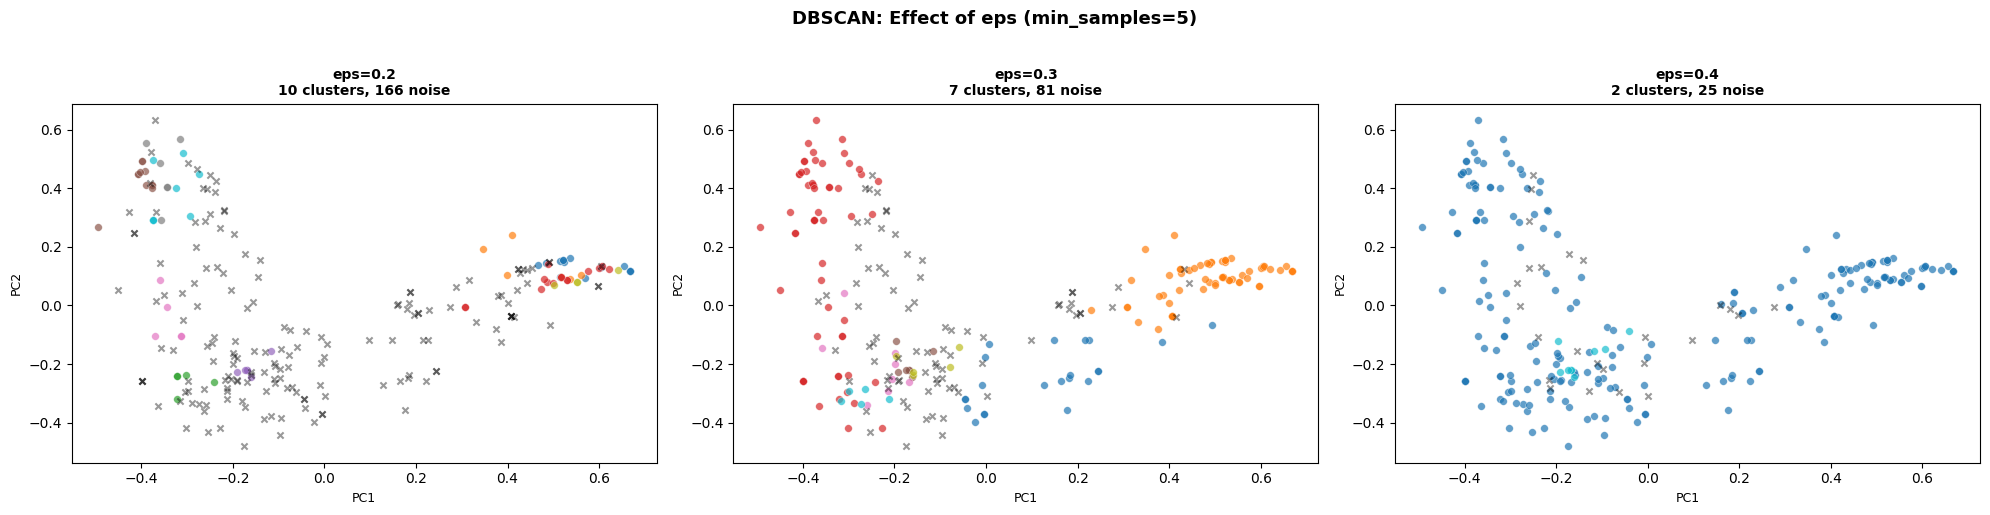

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors_map = plt.cm.tab10

for ax, res in zip(axes, results):
    labels = res['labels']
    unique_labels = set(labels)

    for label in unique_labels:
        mask = labels == label
        if label == -1:
            ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c='black', s=20, alpha=0.4,
                       marker='x', label='Noise')
        else:
            color = colors_map(label / max(max(labels), 1))
            ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], color=color, s=30, alpha=0.7,
                       edgecolors='white', linewidth=0.3)

    n_c = res['n_clusters']
    n_n = res['n_noise']
    ax.set_title(f"eps={res['eps']}\n{n_c} clusters, {n_n} noise", fontsize=10, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)

plt.suptitle('DBSCAN: Effect of eps (min_samples=5)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### **Insights:**

- Proceed with ``eps = 0.3`` as it has the best balance of noise % while still maintaining structure.

#### **Genre Cluster Labels**

In [94]:
dbscan = DBSCAN(eps=0.3, min_samples=5, metric='cosine')
dbscan.fit(tfidf_matrix)

dbscan_labels = dbscan.labels_
artists_df['dbscan_cluster'] = dbscan_labels

for lbl in sorted(set(dbscan_labels)):
    subset = artists_df[artists_df['dbscan_cluster'] == lbl]
    name = f"CLUSTER {lbl}" if lbl != -1 else "NOISE (-1)"

    print(f"{'=' * 70}")
    print(f"{name}  ({len(subset)} artists)")
    print(f"{'=' * 70}")

    for idx, row in subset.sort_values('play_count', ascending=False).iterrows():
        tags = row['tags'] if isinstance(row['tags'], list) else []
        print(f"{row['artist_name']:<30} {row['play_count']:>6}  |  {', '.join(tags)}")

    print()

    if lbl != -1:
        genre_means = tfidf_df.loc[subset.index].mean().sort_values(ascending=False)
        print("Top genres:")
        print(genre_means.head(8).to_string())
    print()

NOISE (-1)  (80 artists)
Title Fight                      2848  |  melodic hardcore, pop punk, punk, punk rock, emo, post-hardcore, shoegaze, hardcore punk
Jaydes                           2385  |  pluggnb, experimental, punk, rock, alternative rock, plugg
Tyler, The Creator               2325  |  hip hop, horrorcore
Radiohead                        2265  |  rock, alternative rock, electronic, experimental, indie rock
Young Thug                       1681  |  trap, hip hop, horrorcore, pop rap, southern hip hop
Nirvana                          1650  |  grunge, rock, alternative rock, punk, hard rock
wifiskeleton                     1582  |  emo, indie rock, slacker rock
TV Girl                          1308  |  indie pop, lo-fi, pop
Ecco2K                            804  |  cloud rap, art pop, emo rap
widowdusk                         710  |  screamo, emo, lo-fi, emoviolence
The Smashing Pumpkins             673  |  alternative rock, grunge, rock, shoegaze, indie rock, hard rock
Clairo

#### **Insights:**

- DBScan has a much more concrete definition of each genre, being conservative with what genres certain artists belong to, while on the other hand K-Means forces each artist into a specifically defined genre of cluster.
- The use of noise *can* be useful in some scenarios where certain artists can be categorized as genre ambiguous (in-between multiple tags / genres that are rarely seen together) or don't really fit anywhere within the defined MusicBrainz genre list.
    - Artists that are classified as noise either have a low amount of tags / genres, or have a unique set of tags that further differentiate them from similar artists
- This resulted in ~30% of artists (76 artists out of 247) to not fully be categorized in a defined cluster.
- Further observation of the noise cluster based on the plot are that they are points that are similar to genre-defined clusters, but are too far away or too distinct from core points of the cluster.

### **Final DBScan Clustering Plot**

DBSCAN cluster names:
  Cluster -1: Noise
  Cluster 0: Electronic / Pop
  Cluster 1: Trap / Hip Hop
  Cluster 2: Emo / Indie Rock
  Cluster 3: Metal / Alternative Metal
  Cluster 4: Slowcore / Lo Fi
  Cluster 5: Indie Folk / Folk
  Cluster 6: Dream Pop / Shoegaze

Final DBSCAN (eps=0.3, min_samples=5)
  Clusters found  : 7
  Noise points    : 81 (32.8%)

Cluster sizes:
                                     Noise: 81 points (32.8%)
                          Electronic / Pop: 22 points (8.9%)
                            Trap / Hip Hop: 62 points (25.1%)
                          Emo / Indie Rock: 57 points (23.1%)
                 Metal / Alternative Metal: 7 points (2.8%)
                          Slowcore / Lo Fi: 8 points (3.2%)
                         Indie Folk / Folk: 5 points (2.0%)
                      Dream Pop / Shoegaze: 5 points (2.0%)


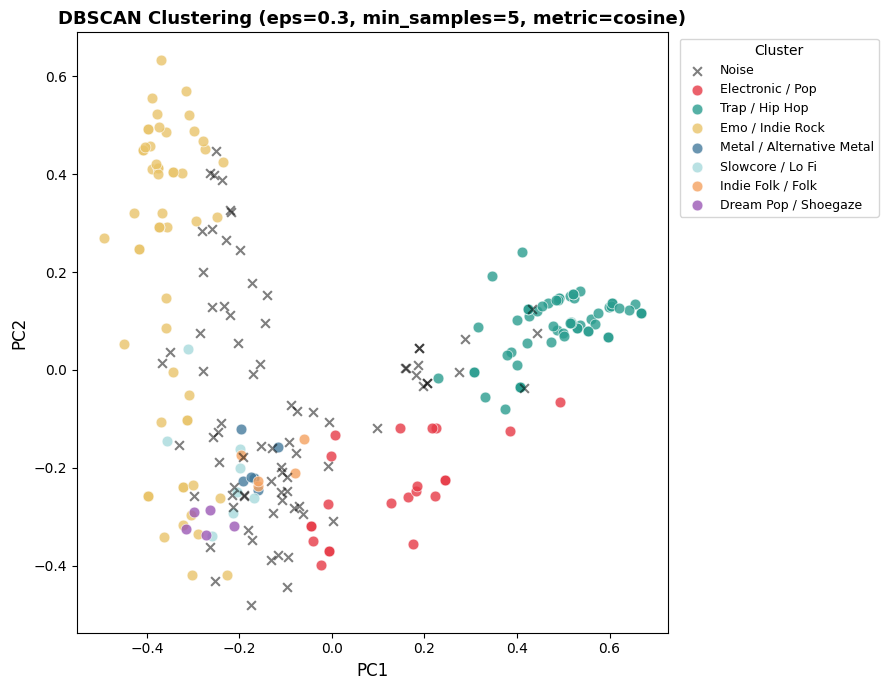

In [97]:
eps_final = 0.3
db_final = DBSCAN(eps=eps_final, min_samples=min_samples, metric='cosine').fit(tfidf_normalized)
artists_df['DBSCAN_Cluster'] = db_final.labels_
labels = db_final.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

# Auto-name DBSCAN clusters from top 2 genres
dbscan_cluster_names = {-1: 'Noise'}
for lbl in sorted(set(labels)):
    if lbl == -1:
        continue
    subset_idx = artists_df[artists_df['DBSCAN_Cluster'] == lbl].index
    genre_means = tfidf_df.loc[subset_idx].mean().sort_values(ascending=False)
    top2 = genre_means.head(2).index.tolist()
    dbscan_cluster_names[lbl] = ' / '.join(g.replace('_', ' ').title() for g in top2)

print("DBSCAN cluster names:")
for lbl, name in dbscan_cluster_names.items():
    print(f"  Cluster {lbl}: {name}")

print(f"\nFinal DBSCAN (eps={eps_final}, min_samples={min_samples})")
print(f"  Clusters found  : {n_clusters}")
print(f"  Noise points    : {n_noise} ({n_noise/len(labels)*100:.1f}%)")
print()
print("Cluster sizes:")
for lbl in sorted(set(labels)):
    count = (labels == lbl).sum()
    name = dbscan_cluster_names[lbl]
    print(f"  {name:>40}: {count} points ({count/len(labels)*100:.1f}%)")

# Visualization
dbscan_palette = {
    -1: 'black',
    0: '#e63946',
    1: '#2a9d8f',
    2: '#e9c46a',
    3: '#457b9d',
    4: '#a8dadc',
    5: '#f4a261',
    6: '#9b59b6'
}

fig, ax = plt.subplots(figsize=(9, 7))

for lbl in sorted(set(labels)):
    mask = labels == lbl
    if lbl == -1:
        ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c='black', s=40, alpha=0.5,
                   marker='x', zorder=5, label=dbscan_cluster_names[-1])
    else:
        ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], color=dbscan_palette[lbl],
                   s=60, alpha=0.8, edgecolors='white', linewidth=0.5,
                   label=dbscan_cluster_names[lbl])

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title(f'DBSCAN Clustering (eps={eps_final}, min_samples={min_samples}, metric=cosine)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, title='Cluster', title_fontsize=10,
          bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### **Insights:**
- ``Emo / Indie Rock``, ``Trap / Hip Hop``, and ``Electronic / Pop`` are the most visible clusters.
- Noise points are very visible inbetween ``Emo / Indie Rock``, ``Slowcore / Lo Fi``, ``Alternative Metal / Metal`` and ``Dream Pop / Shoegaze``
    - Furthermore, besides ``Emo / Indie Rock``, the number of cluster points inbetween are few yet densely packed inbetween each cluster, suggesting that these genres have similarities between each other.
    - This actually is further proven by how each cluster is positioned, ``Trap / Hip Hop`` is close to ``Electronic / Pop``, indicating that these two genres have similarities while it is farthest from ``Emo / Indie Rock``, since there is no overlap between the emo and trap genre.

# **Model Comparison and Evaluation**

## **Final K-Means vs. DBScan Comparison Plot**


Fitting UMAP...
Done.


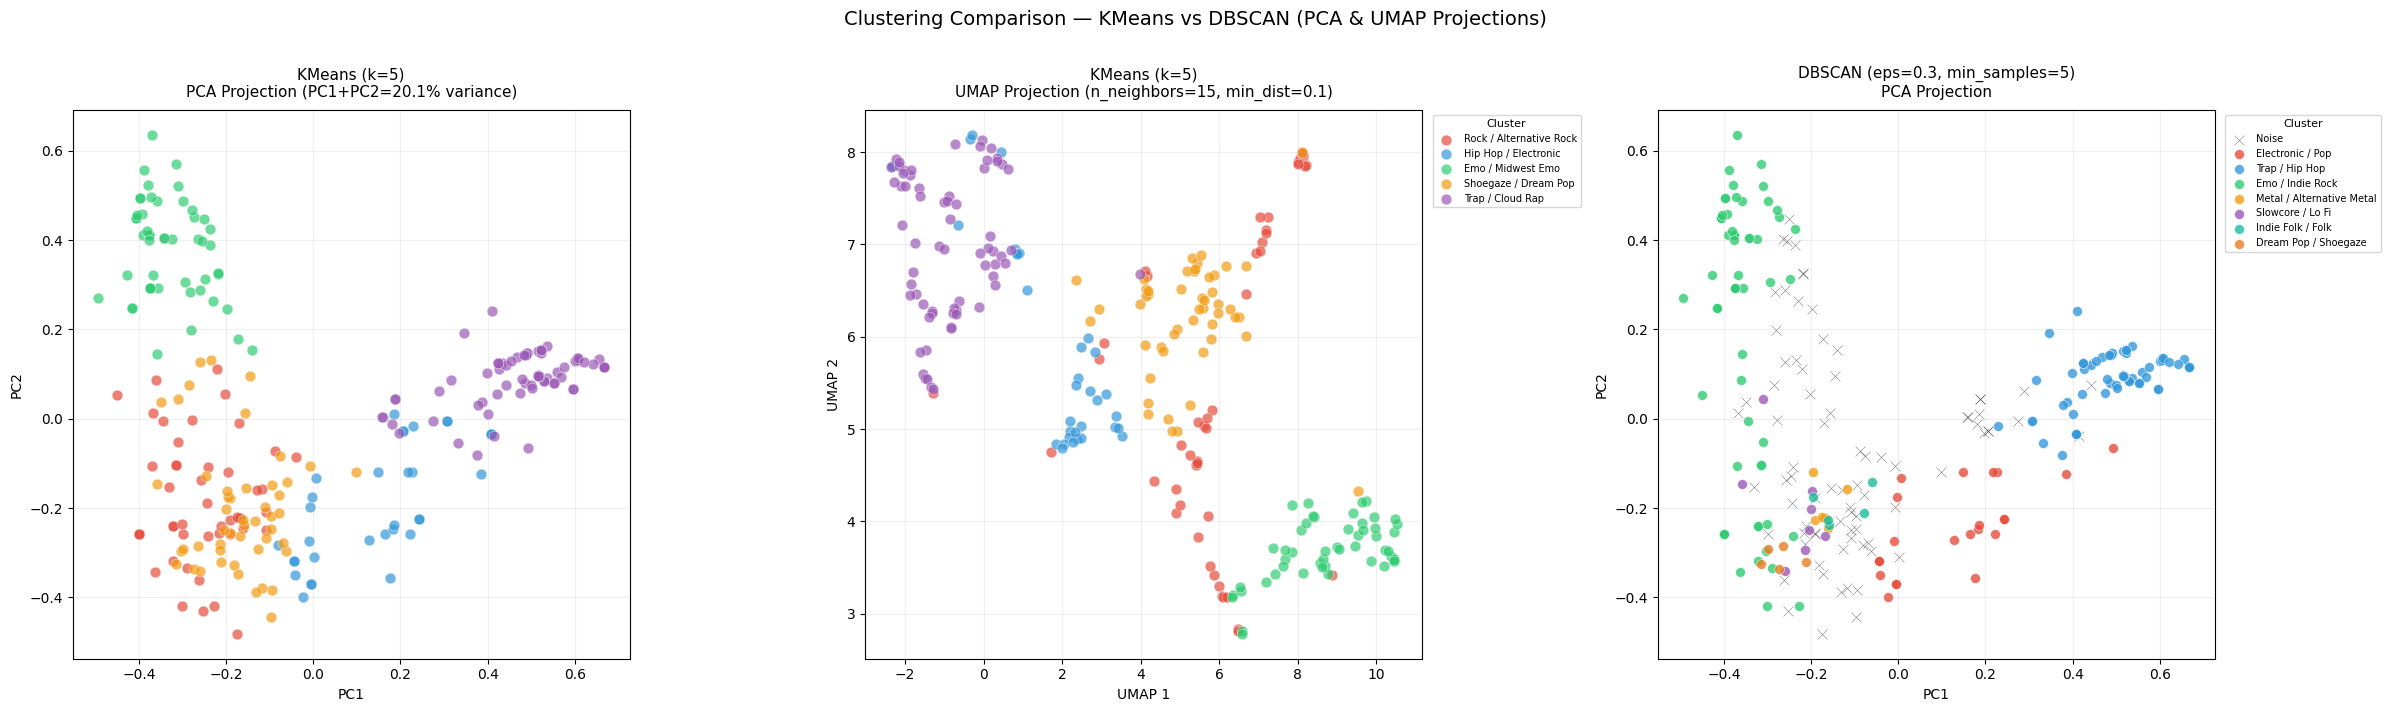

In [100]:
# Auto-name DBSCAN clusters from top 2 genres
dbscan_cluster_names = {-1: 'Noise'}
for lbl in sorted(set(labels)):
    if lbl == -1:
        continue
    subset_idx = artists_df[artists_df['DBSCAN_Cluster'] == lbl].index
    genre_means = tfidf_df.loc[subset_idx].mean().sort_values(ascending=False)
    top2 = genre_means.head(2).index.tolist()
    dbscan_cluster_names[lbl] = ' / '.join(g.replace('_', ' ').title() for g in top2)

# Fit UMAP
print("\nFitting UMAP...")
reducer_final = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_final = reducer_final.fit_transform(tfidf_df)
print("Done.")

# Palettes
dbscan_palette = {
    -1: 'black',
    0: '#e74c3c',
    1: '#3498db',
    2: '#2ecc71',
    3: '#f39c12',
    4: '#9b59b6',
    5: '#1abc9c',
    6: '#e67e22'
}

# 3-panel figure: KMeans PCA | KMeans UMAP | DBSCAN PCA
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- Panel 0: KMeans (PCA projection) ---
for cls in range(len(cluster_names)):
    mask = cluster_labels == cls
    axes[0].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        color=colors[cls],
        label=cluster_names[cls],
        alpha=0.7, s=60,
        edgecolors='white', linewidths=0.4
    )
axes[0].set_title(f'KMeans (k=5)\nPCA Projection (PC1+PC2={sum(pca_2d.explained_variance_ratio_)*100:.1f}% variance)',
                  fontsize=11, pad=10)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.2)

# --- Panel 1: KMeans (UMAP projection) ---
for cls in range(len(cluster_names)):
    mask = cluster_labels == cls
    axes[1].scatter(
        X_umap_final[mask, 0], X_umap_final[mask, 1],
        color=colors[cls],
        label=cluster_names[cls],
        alpha=0.7, s=60,
        edgecolors='white', linewidths=0.4
    )
axes[1].set_title('KMeans (k=5)\nUMAP Projection (n_neighbors=15, min_dist=0.1)',
                  fontsize=11, pad=10)
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(title='Cluster', fontsize=7, title_fontsize=8,
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(True, alpha=0.2)

# --- Panel 2: DBSCAN (PCA projection) ---
for lbl in sorted(set(labels)):
    mask = labels == lbl
    axes[2].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        color=dbscan_palette[lbl],
        label=dbscan_cluster_names[lbl],
        s=50, alpha=0.5 if lbl == -1 else 0.8,
        marker='x' if lbl == -1 else 'o',
        edgecolors='none' if lbl == -1 else 'white',
        linewidths=0.4
    )
axes[2].set_title(f'DBSCAN (eps=0.3, min_samples={min_samples})\nPCA Projection',
                  fontsize=11, pad=10)
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend(title='Cluster', fontsize=7, title_fontsize=8,
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[2].grid(True, alpha=0.2)

plt.suptitle('Clustering Comparison — KMeans vs DBSCAN (PCA & UMAP Projections)',
             fontsize=14, y=1.01)
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()

#### **Insights:**
- Both clustering projections (specifically PCA and DBSCAN) display a relatively non-convex shape.
- Genre taxonomy using clustering algorithms is subjective, two listeners may interpret an artist to be ``midwest emo`` vs. ``indie rock`` which can lead to genres not necessarily being hierarchical 
- **K-Means:**
    - PCA is only able to explain 20.6% of the variance, which means 79.4% of the variance is lost after projecting to 2D. This means the overall complexity of the data is spread out across multiple components rather than a few, suggesting heavy genre overlap.  
    - UMAP on the other hand is able to capture the pattern and non-linearity of genre relationships that PCA can't, resulting in a much better visualization of the data.
    - Overall, UMAP is a better visualization that PCA since it is much more informative in preserving the actual structure of the dataset.  
- **DBScan:**
    - DBScan has a slightly higher silhouette score ``0.2940`` (excluding noise pts.) compared to K-Means's ``0.1313``. Despite this, the amount of Noise % (31.1%) still makes the use of DBScan impractical.
    - Noise points are artists that don't cleanly fit into a genre cluster, either they have a combination of genres that make it an outlier or have a sparse number of tags / genres that doesn't make it fit cleanly as much compared to other clusters.
    - Furthermore, DBScan's visualization reveals uneven genre density, with the ``Trap / Hip Hop`` cluster having as much as 63 points (25.8%) and ``Dream Pop / Shoegaze`` cluster having as low as 4 points (1.6%).
        - This means that sparse clusters bleed into the noise while dense clusters are able to be well-represented.   

  CLUSTERING VALIDATION METRICS: K-MEANS vs DBSCAN
Metric                              K-Means       DBSCAN
------------------------------------------------------------
Number of clusters                        5            7
Noise points                              0           80
Silhouette Score ↑                   0.1279       0.1827
Davies-Bouldin Index ↓               2.5451       1.6192
Calinski-Harabasz ↑                    20.6         14.2
WCSS (Inertia)                       163.88          N/A
------------------------------------------------------------
↑ = higher is better  |  ↓ = lower is better

Note: DBSCAN metrics computed on non-noise points only.


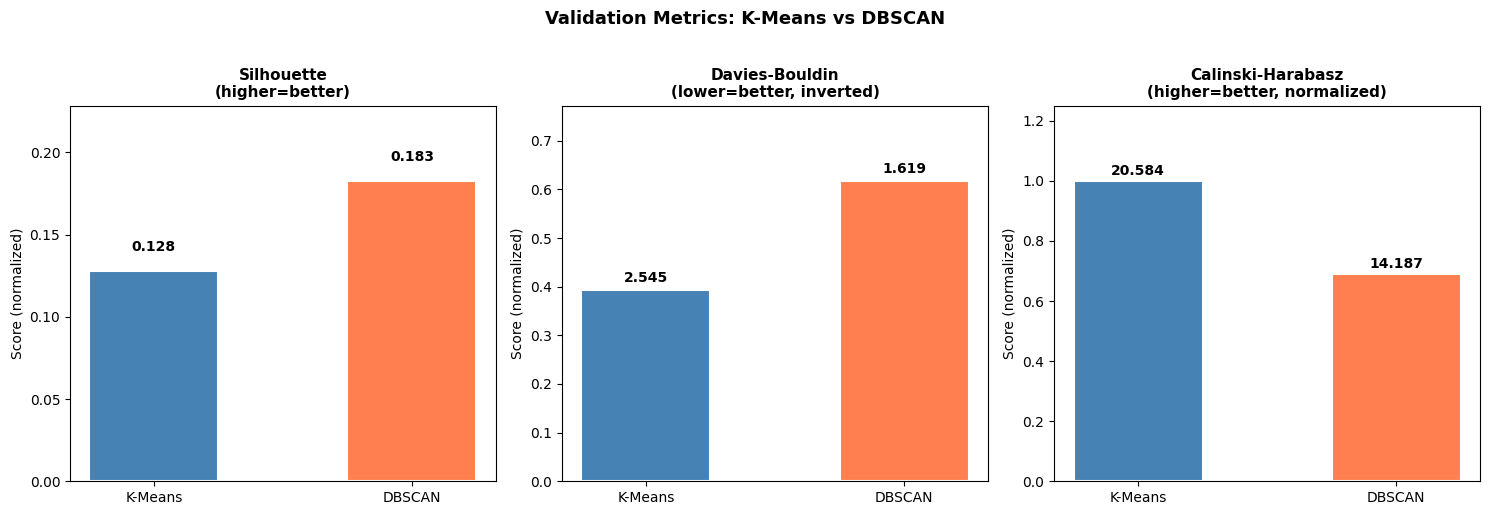

In [122]:
# K-Means metrics
tfidf_dense = tfidf_matrix.toarray()
s_score_k = silhouette_score(tfidf_dense, km_final.labels_)
db_index_k = davies_bouldin_score(tfidf_dense, km_final.labels_)
ch_index_k = calinski_harabasz_score(tfidf_dense, km_final.labels_)
km_wcss = km_final.inertia_

# DBSCAN metrics (exclude noise)
mask_nn = dbscan_labels != -1
X_nn = tfidf_normalized[mask_nn]
labels_nn = dbscan_labels[mask_nn]
s_score_db = silhouette_score(X_nn, labels_nn)
db_index_db = davies_bouldin_score(X_nn, labels_nn)
ch_index_db = calinski_harabasz_score(X_nn, labels_nn)
db_n_noise = (dbscan_labels == -1).sum()
db_n_clusters = len(np.unique(dbscan_labels)) - 1

print("=" * 60)
print("  CLUSTERING VALIDATION METRICS: K-MEANS vs DBSCAN")
print("=" * 60)
print(f"{'Metric':<30} {'K-Means':>12} {'DBSCAN':>12}")
print("-" * 60)
print(f"{'Number of clusters':<30} {'5':>12} {str(db_n_clusters):>12}")
print(f"{'Noise points':<30} {'0':>12} {str(db_n_noise):>12}")
print(f"{'Silhouette Score ↑':<30} {s_score_k:>12.4f} {s_score_db:>12.4f}")
print(f"{'Davies-Bouldin Index ↓':<30} {db_index_k:>12.4f} {db_index_db:>12.4f}")
print(f"{'Calinski-Harabasz ↑':<30} {ch_index_k:>12.1f} {ch_index_db:>12.1f}")
print(f"{'WCSS (Inertia)':<30} {km_wcss:>12.2f} {'N/A':>12}")
print("-" * 60)
print("↑ = higher is better  |  ↓ = lower is better")
print()
print("Note: DBSCAN metrics computed on non-noise points only.")

metrics_labels = ['Silhouette\n(higher=better)',
                  'Davies-Bouldin\n(lower=better, inverted)',
                  'Calinski-Harabasz\n(higher=better, normalized)']

km_raw = [s_score_k, db_index_k, ch_index_k]
db_raw = [s_score_db, db_index_db, ch_index_db]

# Normalize: for DB index, invert (1/x); for CH, divide by max
max_ch = max(ch_index_k, ch_index_db)
km_norm = [s_score_k, 1/db_index_k, ch_index_k/max_ch]
db_norm = [s_score_db, 1/db_index_db, ch_index_db/max_ch]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_bar = ['steelblue', 'coral']

for i, (ax, label, km_v, db_v) in enumerate(zip(axes, metrics_labels, km_norm, db_norm)):
    bars = ax.bar(['K-Means', 'DBSCAN'], [km_v, db_v],
                  color=colors_bar, edgecolor='white', linewidth=1.5, width=0.5)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Score (normalized)', fontsize=10)
    for bar, v in zip(bars, [km_raw[i], db_raw[i]]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(km_v, db_v) * 1.25)

plt.suptitle('Validation Metrics: K-Means vs DBSCAN', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### **Insights:**

- Comparing the two models's metrics side-by-side, K-Means solely wins on CH Index while DBSCAN wins on both silhouette score and DB Index.
- DBSCAN naturally has a higher silhouette score since it filters out artists with a combination of tags considered as "noisy" or outliers.
    - However, this also makes it difficult to justify using DBScan, as one of the main goals for music recommendation is that even through the noise is "Can we shoehorn a genre label on these artists that are within each other's clusters?"
    - Using noise clusters overcomplicates that idea since it penalizes artists that are inbetween clusters, or artists that don't cleanly cluster at all.
- DB Index is used to measure the average similarity of each cluster to other similar clusters where a higher value indicates that the clusters are not well-separated.
    - DBSCAN has the lower DB Index as a result of 
    - Since it is inherently a measure that validates whether clusters are well-separated, it is automatically not suited for K-Means since many artists have different genres which are dependent on the user-tag system of LastFM
    - It should also be noted that DBSCAN has excluded noise pts, which makes DBSCAN is inherently more favored in both Silhouette and DBI.
- Proceed with K-Means despite 1/3 on validation metrics, the amount of data loss with the noise pts of DBSCAN makes recommending artists much more difficult.

# **Final Recommendation System**

## **Fetch artists with $\geq5$ listens**

In [104]:
def get_exclusion_set(user, api_key, min_plays=5):
    """
    Fetches all artists above a minimum play count threshold for exclusion.
    More precise than percentile filtering — excludes genuine listens only.
    """
    listens = set()
    total_pages = None
    page = 1

    while total_pages is None or page <= total_pages:
        try:
            r = requests.get(
                "http://ws.audioscrobbler.com/2.0/",
                params={
                    'method': 'library.getartists',
                    'user': user,
                    'api_key': api_key,
                    'format': 'json',
                    'limit': 1000,
                    'page': page
                }
            )
            r.raise_for_status()
            data = r.json()['artists']
            if total_pages is None:
                total_pages = int(data['@attr']['totalPages'])
            for artist in data['artist']:
                if int(artist['playcount']) >= min_plays:
                    listens.add(artist['name'].lower())
            print(f"Page {page}/{total_pages} — {len(listens)} artists collected")
            page += 1
            time.sleep(0.25)
        except Exception as e:
            print(f"Error on page {page}: {e}")
            break

    print(f"Total artists to exclude (>= {min_plays} plays): {len(listens)}")
    return listens

casual_listened = get_exclusion_set(user, API_KEY, min_plays=5)

Page 1/3 — 917 artists collected
Page 2/3 — 917 artists collected
Page 3/3 — 917 artists collected
Total artists to exclude (>= 5 plays): 917


#### **Insights:**
- Use ``casual_listened`` for the recommendation system, which includes casual listened artists.
- 914 total artists have >= 5 plays

## **Generate Candidate Pool**

In [107]:
lock = threading.Lock()

# Fetch candidate artist pool from Last.fm
existing_artists = set(artists_df['artist_name'].str.lower())
candidate_pool = {}

def fetch_similar(artist_name):
    local_candidates = {}
    try:
        similar = network.get_artist(artist_name).get_similar(limit=10)
        for item in similar:
            name = item.item.name
            name_lower = name.lower()
            if name_lower not in casual_listened:
                local_candidates[name_lower] = item.item
        time.sleep(0.1)
    except Exception as e:
        print(f"Skipped '{artist_name}': {e}")
    return local_candidates

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(fetch_similar, name): name for name in artists_df['artist_name']}
    for future in as_completed(futures):
        result = future.result()
        with lock:
            for k, v in result.items():
                if k not in candidate_pool:
                    candidate_pool[k] = v

print(f"Candidate pool size: {len(candidate_pool)} artists")

Candidate pool size: 993 artists


**Insights:**
- Utilized ThreadPoolExecutor to speed up API requests.
- ``fetch_similar`` function checks if the candidate artist has already been listened to through the extensive ``casual_listened`` dataframe and excludes them.
- 957 artists is enough for recommending candidate artists.

## **Fetch tags for candidates**

In [110]:
# Reuse the same logic from data collection stage
def fetch_candidate_tags(item):
    name, artist_obj = item
        
    tags = []
    try:
        raw_tags = artist_obj.get_top_tags(limit=10)
        tags = [t.item.name.lower() for t in raw_tags if int(t.weight) >= 10]
    except Exception:
        pass

    if not tags:
        try:
            mb_result = musicbrainzngs.search_artists(artist=name, limit=1)
            mb_tags = mb_result['artist-list'][0].get('tag-list', [])
            tags = [t['name'].lower() for t in mb_tags]
        except Exception:
            pass

    return {'artist_name': name, 'tags': tags} if tags else None

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(fetch_candidate_tags, item): item for item in candidate_pool.items()}
    candidate_records = []
    dropped = 0
    for future in as_completed(futures):
        result = future.result()
        if result:
            candidate_records.append(result)
        else:
            dropped += 1
            
candidate_df = pd.DataFrame(candidate_records)
print(f"Candidates with tags: {len(candidate_df)} | Dropped (no tags / filtered): {dropped}")

Candidates with tags: 968 | Dropped (no tags / filtered): 25


## **Transform candidates using TF-IDF**

In [112]:
# Transform candidates using the FITTED vectorizer 
# Mirror existing tag-joining logic exactly
candidate_tags_joined = candidate_df['tags'].apply(lambda t: ' '.join(t))
candidate_tfidf = tfidf.transform(candidate_tags_joined)  # transform only, not fit_transform

## **Cosine Similarity**

In [114]:
# Rebuild from source to avoid stale state on re-runs
candidate_df = pd.DataFrame(candidate_records).reset_index(drop=True)
candidate_tags_joined = candidate_df['tags'].apply(lambda t: ' '.join(t))
candidate_tfidf = tfidf.transform(candidate_tags_joined)

# Cosine similarity: candidates vs existing artists
# Shape: (n_candidates × 247)
candidate_sim = cosine_similarity(candidate_tfidf, tfidf_matrix)

# Max similarity across all artists for each candidate
candidate_df['max_similarity'] = candidate_sim.max(axis=1)

# Drop candidates with no tag overlap — cosine similarity undefined for zero vectors
valid_mask = (candidate_df['max_similarity'] > 0).to_numpy()
candidate_df = candidate_df[valid_mask].reset_index(drop=True)
candidate_sim = candidate_sim[valid_mask]
candidate_tfidf = candidate_tfidf[valid_mask]

# Index of the most similar artist listened to
best_match_idx = candidate_sim.argmax(axis=1)
candidate_df['closest_artist'] = artists_df['artist_name'].iloc[best_match_idx].values
candidate_df['closest_cluster'] = artists_df['cluster'].iloc[best_match_idx].values

# Join play count of closest artist onto candidate_df
artist_play_counts = artists_df.set_index('artist_name')['play_count']
candidate_df['closest_artist_play_count'] = candidate_df['closest_artist'].map(artist_play_counts)

# Weighted score: similarity scaled by how much you listen to the closest artist
candidate_df['weighted_score'] = candidate_df['max_similarity'] * candidate_df['closest_artist_play_count']

## **Recommend by Cluster**

In [116]:
def recommend_new_artists(top_n=10, cluster_filter=None, balanced=True, sort_by='weighted_score'):
    """
    sort_by options:
        'weighted_score'  : max_similarity scaled by closest artist play count (default)
        'max_similarity'  : cosine similarity only
        'play_count'      : closest artist play count only
    """
    valid_sort = ['weighted_score', 'max_similarity', 'play_count']
    if sort_by not in valid_sort:
        raise ValueError(f"sort_by must be one of {valid_sort}")

    # Map sort_by to actual column
    sort_col = 'closest_artist_play_count' if sort_by == 'play_count' else sort_by

    output_cols = ['artist_name', 'weighted_score', 'max_similarity', 'closest_artist', 'closest_artist_play_count', 'closest_cluster']

    df = candidate_df.copy()

    if cluster_filter is not None:
        cluster_filter = [cluster_filter] if not isinstance(cluster_filter, (list, tuple)) else cluster_filter
        df = df[df['closest_cluster'].isin(cluster_filter)]
        if df.empty:
            raise ValueError(f"No candidates matched clusters {cluster_filter}")
        return (
            df.sort_values(sort_col, ascending=False)
            .head(top_n)[output_cols]
            .reset_index(drop=True)
        )

    if balanced:
        clusters = sorted(df['closest_cluster'].unique())
        per_cluster = max(1, top_n // len(clusters))
        remainder = top_n - (per_cluster * len(clusters))

        chunks = []
        for cluster in clusters:
            subset = (
                df[df['closest_cluster'] == cluster]
                .sort_values(sort_col, ascending=False)
                .head(per_cluster)
            )
            chunks.append(subset)

        result = pd.concat(chunks)

        included_idx = result.index
        remaining = (
            df[~df.index.isin(included_idx)]
            .sort_values(sort_col, ascending=False)
            .head(remainder)
        )
        result = pd.concat([result, remaining])

        return (
            result.sort_values(['closest_cluster', sort_col], ascending=[True, False])
            [output_cols]
            .reset_index(drop=True)
        )

    else:
        return (
            df.sort_values(sort_col, ascending=False)
            .head(top_n)[output_cols]
            .reset_index(drop=True)
        )

recommend_new_artists(top_n=10, cluster_filter=4)

,artist_name,weighted_score,max_similarity,closest_artist,closest_artist_play_count,closest_cluster
0,bbyafricka,3463.152549,0.819681,Lucki,4225,4
1,bladee & mechatok,3463.152549,0.819681,Lucki,4225,4
2,24kgoldn,3463.152549,0.819681,Lucki,4225,4
3,bankrol hayden,3463.152549,0.819681,Lucki,4225,4
4,cashcache!,288.000000,1.000000,Fulcrum,288,4
5,yung fazo,288.000000,1.000000,Fulcrum,288,4
6,10kdunkin,288.000000,1.000000,Fulcrum,288,4
7,septembersrich,288.000000,1.000000,Fulcrum,288,4
8,islurwhenitalk,288.000000,1.000000,Fulcrum,288,4
9,ohsxnta,270.311917,0.938583,Fulcrum,288,4


#### **Insights:**
- Recommend by cluster takes into account the ``max_similarity`` score (how similar an artist is to a listened artist)
    - I obtain the maximum similarity since it's important to see the most similar artists based on our listening data
- By default it is sorted by the ``weighted_score`` parameter which is computed by multiplying the play count of the closest listened artist and the ``max_similarity`` score in order to best show the most relevant artists to the user.
- It also has a ``closest_cluster`` parameter to filter by genre cluster (i.e, cluster 0 which is Rock / Alternative Rock).
- ``balanced`` parameter allows the function to show multiple clusters at once, if False it sorts it by ``sort_by`` parameter in descending order.

## **Recommend by Artist**

In [119]:
def recommend_by_artist(artist_name, top_n=10):
    name_lower = artist_name.strip().lower()
    match = artists_df[artists_df['artist_name'].str.lower() == name_lower]

    if match.empty:
        raise ValueError(f"Artist '{artist_name}' not found in your listened artists.")

    idx = match.index[0]
    query_cluster = artists_df.loc[idx, 'cluster']

    artist_scores = cosine_similarity(
        candidate_tfidf,
        tfidf_matrix[idx]
    ).flatten()

    candidate_df_copy = candidate_df.copy()
    candidate_df_copy['similarity_to_artist'] = artist_scores

    return (
        candidate_df_copy[candidate_df_copy['similarity_to_artist'] > 0]
        .sort_values('similarity_to_artist', ascending=False)
        .head(top_n)[['artist_name', 'similarity_to_artist', 'closest_cluster']]
        .assign(queried_artist=artist_name, queried_cluster=query_cluster)
        .reset_index(drop=True)
    )

recommend_by_artist("My Chemical Romance", top_n=10)

,artist_name,similarity_to_artist,closest_cluster,queried_artist,queried_cluster
0,worst party ever,0.565117,2,My Chemical Romance,2
1,glocca morra,0.565117,2,My Chemical Romance,2
2,poorstacy,0.547318,2,My Chemical Romance,2
3,pencey prep,0.506665,2,My Chemical Romance,2
4,yellowcard,0.506622,2,My Chemical Romance,2
5,box car racer,0.506622,2,My Chemical Romance,2
6,midtown,0.506622,2,My Chemical Romance,2
7,alkaline trio,0.506622,2,My Chemical Romance,2
8,remo drive,0.487460,2,My Chemical Romance,2
9,the network,0.482489,2,My Chemical Romance,2


# **Final Observations:**
### **1. Data Collection**
- The use of last.fm's API allows me to make personalized music recommendations based on artist's scrobble counts and overall genre clustering.
    - There was potential in using other open source API's such as Spotify or MusicBrainz, however I settled on using LastFM as it has a much more extensive source of listen counts and artist profiles over other API sources.
    - The main limitation of LastFM is that it requires you to make an account and a scrobbling source (i.e. Spotify or any other supported scrobbling source), and only then will LastFM track your listening data. Due to this, it'd require a fair amount of time to build up a large amount of listening data. 
- The sourced API data uses an optimal limit parameter that takes the 75th percentile of all listens in order to determine the threshold for actual meaningful listens, rather than accidental ones.

### **2. Data Preparation**
- In order to properly further streamline last.fm's user-based tagging system, I used MusicBrainz.org's list of valid genres and matched it with last.fm's user-based tagging system in order to classify an artist's genre.
  - There are a few limitations with this system, mainly that it is more dependent on users actually making use of tags to classify an artist's genre. An underground artist may have sparse tags making their data unusable.
  - Another limitation is that genre classification is inherently arbitrary, which can lead to inconsistent tagging of certain artists.

### **3. EDA**
- EDA showed that my user's listening history would be heavily right skewed, showing that artists with a large number of listens are outliers and most artists play counts fall anywhere between $\small \leq500$ total scrobbles. Furthermore, most artists have around 4 tags, though there are still a few artists with 1 tag only. Lastly, genres you'd expect to be paired up with have high correlation scores between each other, while genres that are generally not paired with each other have low correlation scores.

### **4. Data Modeling**
- K-Means clustering on the TF-IDF feature matrix revealed genre clusters having substantial overlap with weak boundaries (further proven with 0.134 silhouette score). This can be visualized by projecting the high-dimensional clustering results onto a 2-dimensional plane, showing each artist and genre's similarities and differences.
    - The clusters having substantial overlap as well as a low silhouette score is an expected byproduct of genre and user-based tags and boundaries being subjective rather than objective truths; one artist could be labeled indie rock by Last.fm while in fact it might be closer to emo in one's eyes. 
    - The K-Means model overall makes up for this, rather than being specific in categorizing artists into pigeonholed genres, it groups similar sounding artists into shared clusters of genres.  

### **5. Recommendation Algorithm**
- The recommendation algorithm makes use of two functions, ``recommend_new_artists`` (also named recommend by cluster) and ``recommend_by_artist``. It shows the recommended artist's name, its weighted score, and the cosine similarity score.
    - The recommendation algorithm scans the user's listening data, first scraping from the user's unique LastFM artists, and determining which artists have $\small \geq5$ total scrobbles, to which these artists would be excluded from being recommended. 
    - Afterwards, it generates a candidate pool using LastFM's ``artist.getSimilar`` from each artist in the original artists_df. 
    - It will then proceed to fetch tags for each candidate, and then prune candidates with null tags. 
    - Next, this candidate pool will be transformed using TF-IDF and then utilize cosine similarity to determine how similar a candidate is to an artist that it is most similar to, taking note of its closest cluster as well. 
    - It will then join ``play_counts`` to ``candidate_df``, and then scale ``max_similarity`` with ``play_counts`` to determine the total weighted score of an artist.

---
## **References:**
Anthropic. (2026). Claude. Claude.ai. https://claude.ai/new <br>
Last.fm. (2026). https://www.last.fm/ <br>
MusicBrainz. (2026). Genre list. MusicBrainz - the open music encyclopedia. https://musicbrainz.org/genres